# 🤝 Ensembles — Voting, Stacking & AdaBoost

> **What you'll learn:** why combining models works (and when it doesn't), hard vs soft voting, stacking with out-of-fold predictions and why in-sample stacking leaks, blending, and AdaBoost from its sample-weight updates to its exponential-loss derivation. You'll measure diversity, label-noise sensitivity and the latency cost of ensembles, and rebuild AdaBoost and soft voting to match scikit-learn exactly.

| | |
|---|---|
| **Difficulty** | 🟢 Beginner → 🟡 Intermediate → 🔴 Interview depth |
| **Time** | ~4 hours to read and run, +2 hours for exercises and the project |
| **Prerequisites** | [Gradient Boosting](10_Gradient_Boosting.ipynb) (boosting, early stopping) · [Random Forests & Bagging](09_Random_Forest_and_Bagging.ipynb) (bagging, variance of averages, OOB) · [Scikit-Learn](02_Scikit_Learn.ipynb) (pipelines, cross-validation) |
| **Tested with** | Python 3.12 · scikit-learn 1.9 · mlxtend 0.25 · scipy 1.18 · pandas 3.0 · numpy 2.5 |
| **Interview relevance** | ⭐⭐⭐ High — "why do ensembles work?", hard vs soft voting, stacking leakage and out-of-fold predictions, AdaBoost's weights and exponential loss, bagging vs boosting vs stacking, "is the ensemble worth it in production?" |

## 🤔 What Is an Ensemble?

Picture a hospital deciding whether a scan shows a tumour.

- **Voting:** five doctors look at the scan. In a *hard* vote each says yes or no and the majority wins. In a *soft* vote each gives a confidence ("80% sure") and the average confidence decides.
- **Stacking:** a head physician has watched these doctors on **past cases they hadn't studied**. She learned whom to trust ("the radiologist is right about small tumours, the oncologist about large ones") and combines their opinions accordingly.
- **AdaBoost:** a study group. The first student answers every question. The second concentrates on the questions the first got wrong, the third on what's *still* wrong, and so on. At the end, students who were more accurate get a bigger say.

An **ensemble** is any model built by combining several models (the **base models** or **base learners**). The combination only helps if the models make **different** mistakes: five doctors who always agree are no better than one.

| Family | How models are trained | How they're combined | Main effect |
|---|---|---|---|
| **Bagging** ([notebook 09](09_Random_Forest_and_Bagging.ipynb)) | same model, bootstrap samples, in parallel | average / vote | lowers variance |
| **Boosting** (AdaBoost here, [gradient boosting](10_Gradient_Boosting.ipynb)) | weak models, **sequentially**, each focusing on earlier errors | weighted sum | lowers bias |
| **Voting** | different models, independently | (weighted) average / vote | lowers variance if errors differ |
| **Stacking** | different models + a **meta-model** trained on their out-of-fold predictions | learned combination | learns whom to trust |

## 🎯 Why It Matters

- **Winning solutions are ensembles.** The Netflix Prize and most Kaggle competitions were won by blends and stacks of many models.
- **Production systems combine models too:** fraud scoring that averages a gradient-boosted model with a neural net, search ranking that blends several rankers, medical tools that ensemble models trained on different hospitals.
- **AdaBoost made history.** The Viola–Jones face detector (2001), which ran on early digital cameras, is a cascade of AdaBoost classifiers built from simple features. AdaBoost's analysis also led to the statistical view of boosting behind today's gradient boosting.
- **The costs are real:** every extra model adds latency, memory, training time and maintenance. Knowing when an ensemble *isn't* worth it is a senior-level skill.
- **In interviews:** *"Why do ensembles work?"*, *"Hard vs soft voting?"*, *"How does stacking avoid leakage?"*, *"Walk me through AdaBoost"*, *"Why is AdaBoost sensitive to noise?"*, *"Bagging vs boosting vs stacking?"*, *"Would you deploy a 5-model stack?"*

## 🃏 Algorithm Card

| | Voting | Stacking / blending | AdaBoost (SAMME) |
|---|---|---|---|
| **Learning type** | Supervised meta-algorithm | Supervised meta-algorithm (two levels) | Supervised boosting |
| **Tasks** | Classification (`VotingClassifier`), regression (`VotingRegressor`) | Classification, regression (`StackingClassifier/Regressor`) | Classification (SAMME), regression (`AdaBoostRegressor`, AdaBoost.R2) |
| **Model / objective** | Soft: $\hat p(k\mid x)=\frac{\sum_m w_m\, p_m(k\mid x)}{\sum_m w_m}$; hard: weighted majority of labels. Nothing extra is optimized. | A meta-model $g$ minimizes its own loss on **out-of-fold** base predictions $\hat z(x)$: $\hat y = g(\hat z_1(x),\dots,\hat z_M(x))$ | Additive model $F(x)=\sum_m \alpha_m h_m(x)$ built by forward stagewise minimization of the **exponential loss** $\sum_i e^{-y_i F(x_i)}$ |
| **Key hyperparameters** | `voting` (hard/soft), `weights` | `final_estimator` (a simple regularized model), `cv` (5), `stack_method`, `passthrough` | `estimator` (stump by default), `n_estimators` (50–1000), `learning_rate` (0.05–1) |
| **Needs feature scaling?** | Depends on the base models: scale **inside** each base pipeline | Same; nothing inside the stack scales for you | No (tree stumps) |
| **Missing values / categoricals** | Whatever each base model supports | Whatever each base model supports | Encode categoricals first; missing-value support depends on the base estimator |
| **Training & prediction complexity** | Sum of the base models | Training ≈ (`cv` + 1) × base models + meta-model; prediction = all base models + meta | $M$ sequential weak-learner fits; prediction = $M$ stumps (fast) |
| **Interpretability** | Low (inherits the base models) | Low; meta-model weights show whom it trusts | Moderate with stumps: a weighted sum of one-feature rules |
| **Strengths** | Simple, robust gains when members are diverse | Often the best score; learns weights and interactions | Few knobs, strong on clean data, simple theory |
| **Weaknesses** | No gain when errors are correlated; soft voting needs calibrated probabilities | Costly, leakage risk, latency, maintenance | **Concentrates weight on mislabeled rows and outliers** (costly with flexible learners); sequential; usually beaten by gradient boosting |
| **Use it when** | You already have several good, different models | Competitions, offline scoring, or when accuracy dominates cost | Clean data, a small fast model, teaching boosting |
| **Avoid it when** | Models are near-copies, or latency is tight | Tight latency budgets, small teams, tiny data | Noisy labels, outliers, when gradient boosting is available |
| **Best libraries** | scikit-learn `VotingClassifier`, mlxtend `EnsembleVoteClassifier` | scikit-learn `StackingClassifier` + `FrozenEstimator` (blending), mlxtend `StackingCVClassifier` | scikit-learn `AdaBoostClassifier` |

## ✅ By the End You Can

- [ ] Explain why ensembles work using error correlation, and measure diversity between real models
- [ ] Choose hard vs soft voting and pick weights without leaking
- [ ] Build stacking with out-of-fold predictions, explain why in-sample stacking leaks, and implement blending
- [ ] Walk through AdaBoost (SAMME): sample-weight updates, learner weights, and the exponential-loss derivation
- [ ] Show AdaBoost's sensitivity to label noise and decide, with numbers, when an ensemble isn't worth its latency
- [ ] Implement AdaBoost and soft voting from scratch and match scikit-learn exactly

## 📋 Table of Contents

1. [Why Ensembles Work: Diversity and Error Correlation](#1.-Why-Ensembles-Work:-Diversity-and-Error-Correlation-🟢)
2. [Hard vs Soft Voting and Weights](#2.-Hard-vs-Soft-Voting-and-Weights-🟢)
3. [Stacking With Out-of-Fold Predictions](#3.-Stacking-With-Out-of-Fold-Predictions-🟡)
4. [Why In-Sample Stacking Leaks](#4.-Why-In-Sample-Stacking-Leaks-🔴)
5. [Blending: Stacking With a Holdout Set](#5.-Blending:-Stacking-With-a-Holdout-Set-🟡)
6. [AdaBoost: The SAMME Algorithm](#6.-AdaBoost:-The-SAMME-Algorithm-🟡)
7. [AdaBoost as Exponential-Loss Minimization](#7.-AdaBoost-as-Exponential-Loss-Minimization-🔴)
8. [Decision Stumps as Weak Learners](#8.-Decision-Stumps-as-Weak-Learners-🟢)
9. [Learning Rate vs Number of Estimators](#9.-Learning-Rate-vs-Number-of-Estimators-🟡)
10. [Sensitivity to Label Noise and Outliers](#10.-Sensitivity-to-Label-Noise-and-Outliers-🔴)
11. [Bagging vs Boosting vs Stacking: A Fair Head-to-Head](#11.-Bagging-vs-Boosting-vs-Stacking:-A-Fair-Head-to-Head-🟡)
12. [When Ensembles Aren't Worth It](#12.-When-Ensembles-Aren't-Worth-It-🟡)
- [🔧 Build It From Scratch](#🔧-Build-It-From-Scratch) · [⚠️ Common Pitfalls](#⚠️-Common-Pitfalls) · [🏋️ Practice Exercises](#🏋️-Practice-Exercises) · [🚀 Mini Project](#🚀-Mini-Project:-Is-a-Four-Model-Stack-Worth-It-for-Spam-Filtering?) · [🎤 Interview Q&A](#🎤-Interview-Q&A) · [🧪 Quick Quiz](#🧪-Quick-Quiz) · [📚 Resources](#📚-Resources) · [📝 Summary](#📝-Summary-Cheat-Sheet)

## ⚙️ Setup

Run the cell below first. If a library is missing, uncomment the `%pip` line, run it once, then restart the kernel.

The `check()` helper gives you instant feedback on exercises: **✅** correct, **⏳** not attempted yet, **❌** wrong (with a hint).

**Datasets (all real):**
- **Spambase** (OpenML id 44, ~1 MB): 4,601 emails from Hewlett-Packard (1999), 57 numeric features (word and character frequencies, runs of capital letters), label = spam or not. Most sections use it.
- **Breast cancer Wisconsin** and **Wine** (bundled with scikit-learn): small datasets for AdaBoost walk-throughs and a 3-class check.
- **California housing** (scikit-learn download, ~0.4 MB): one stacking-regression example.

We keep features as NumPy arrays: AdaBoost's `staged_*` methods warn when a model is fitted on a DataFrame (⚠️ Pitfall 6).

In [1]:
# %pip install -q "scikit-learn>=1.6" "mlxtend>=0.23" "scipy>=1.11" "pandas>=2.2" "numpy>=2.0" matplotlib

import gc
import math
import pickle
import sys
import time
import warnings
from itertools import combinations

import matplotlib.pyplot as plt
import mlxtend
import numpy as np
import pandas as pd
import scipy
import sklearn
from mlxtend.classifier import StackingCVClassifier
from scipy.optimize import minimize_scalar
from scipy.special import softmax
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.datasets import fetch_california_housing, fetch_openml, load_breast_cancer, load_wine
from sklearn.ensemble import (
    AdaBoostClassifier,
    BaggingClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    HistGradientBoostingRegressor,
    RandomForestClassifier,
    StackingClassifier,
    StackingRegressor,
    VotingClassifier,
)
from sklearn.frozen import FrozenEstimator
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import accuracy_score, log_loss, r2_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_validate, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

print(f"Python {sys.version.split()[0]} | scikit-learn {sklearn.__version__} | mlxtend {mlxtend.__version__} | "
      f"scipy {scipy.__version__} | pandas {pd.__version__} | numpy {np.__version__}")

SEED = 42
pd.set_option("display.precision", 4)
pd.set_option("display.width", 140)


def check(name, got, expected, hint="", rtol=1e-4, atol=1e-6):
    """✅ if correct, ⏳ if not attempted yet (None), ❌ AssertionError with a hint otherwise."""
    if got is None or got is ...:
        print(f"⏳ {name}: not attempted yet — replace None with your answer.")
        return
    if isinstance(expected, dict):
        ok = isinstance(got, dict) and set(got) == set(expected) and all(
            np.allclose(got[k], expected[k], rtol=rtol, atol=atol) for k in expected)
    elif isinstance(expected, (bool, np.bool_, str)):
        ok = got == expected
    else:
        try:
            g, e = np.asarray(got, dtype=float), np.asarray(expected, dtype=float)
        except (TypeError, ValueError):
            raise AssertionError(f"❌ {name}: expected a number/array, got {type(got).__name__}. {hint}")
        if g.shape != e.shape:
            raise AssertionError(f"❌ {name}: shape {g.shape}, expected {e.shape}. {hint}")
        ok = np.allclose(g, e, rtol=rtol, atol=atol)
    assert ok, f"❌ {name}: not quite. {hint}"
    print(f"✅ {name}: correct!")


def median_latency_ms(model, X_one, repeats=50):
    """Median wall-clock time of model.predict on a single row, in milliseconds."""
    model.predict(X_one)                                      # warm-up
    timings = []
    for _ in range(repeats):
        start = time.perf_counter()
        model.predict(X_one)
        timings.append(time.perf_counter() - start)
    return 1000 * float(np.median(timings))


def pickle_mb(obj):
    return len(pickle.dumps(obj, protocol=pickle.HIGHEST_PROTOCOL)) / 1e6

Python 3.12.11 | scikit-learn 1.9.1 | mlxtend 0.25.0 | scipy 1.18.1 | pandas 3.0.5 | numpy 2.5.3


## 1. Why Ensembles Work: Diversity and Error Correlation 🟢

**The idealized math.** Suppose $M$ classifiers each have accuracy $p > 0.5$ and make mistakes **independently**. A majority vote is correct when more than half are correct, which is a binomial probability:

$$P(\text{majority correct}) = \sum_{k > M/2} \binom{M}{k}\, p^k (1-p)^{M-k}$$

With $p = 0.7$, 5 voters reach 0.837 and 21 voters 0.974. This is **Condorcet's jury theorem**. The catch is the word *independently*: real models trained on the same data make **correlated** mistakes (Section 2 of [notebook 09](09_Random_Forest_and_Bagging.ipynb) showed the same effect for averages: variance $\rho\sigma^2 + \frac{1-\rho}{B}\sigma^2$).

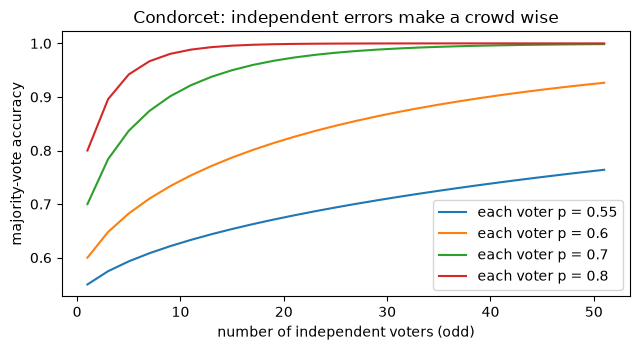

 1 independent voters at p=0.7 → majority accuracy 0.7000
 3 independent voters at p=0.7 → majority accuracy 0.7840
 5 independent voters at p=0.7 → majority accuracy 0.8369
11 independent voters at p=0.7 → majority accuracy 0.9218
21 independent voters at p=0.7 → majority accuracy 0.9736


In [2]:
def majority_accuracy(p, n_voters):
    return sum(math.comb(n_voters, k) * p ** k * (1 - p) ** (n_voters - k) for k in range(n_voters // 2 + 1, n_voters + 1))


voters = np.arange(1, 52, 2)
fig, ax = plt.subplots(figsize=(6.5, 3.6))
for p in [0.55, 0.6, 0.7, 0.8]:
    ax.plot(voters, [majority_accuracy(p, m) for m in voters], label=f"each voter p = {p}")
ax.set(xlabel="number of independent voters (odd)", ylabel="majority-vote accuracy",
       title="Condorcet: independent errors make a crowd wise")
ax.legend()
plt.tight_layout()
plt.show()
for m in [1, 3, 5, 11, 21]:
    print(f"{m:>2} independent voters at p=0.7 → majority accuracy {majority_accuracy(0.7, m):.4f}")

**Real models.** Load Spambase. We split once into a **development** set (80%) for all sections and a **test** set (20%) used only once, at the end of the 🚀 Mini Project. Sections 1–12 split the development set again into a **fit** part and a **validation** part.

In [3]:
spam = fetch_openml(data_id=44, as_frame=True)
spam_features = spam.data.columns.tolist()
X_spam = spam.data.to_numpy(dtype=float)
y_spam = spam.target.astype(int).to_numpy()                         # 1 = spam
X_dev, X_test, y_dev, y_test = train_test_split(X_spam, y_spam, test_size=0.2, stratify=y_spam, random_state=SEED)
X_fit, X_val, y_fit, y_val = train_test_split(X_dev, y_dev, test_size=0.25, stratify=y_dev, random_state=SEED)
print(f"{X_spam.shape[0]:,} emails × {X_spam.shape[1]} features | spam rate {y_spam.mean():.1%}")
print(f"development {len(X_dev):,} (fit {len(X_fit):,} · validation {len(X_val):,}) · test {len(X_test):,} (locked away)")
print("a few features:", spam_features[:3], "...", spam_features[-3:])

4,601 emails × 57 features | spam rate 39.4%
development 3,680 (fit 2,760 · validation 920) · test 921 (locked away)
a few features: ['word_freq_make', 'word_freq_address', 'word_freq_all'] ... ['capital_run_length_average', 'capital_run_length_longest', 'capital_run_length_total']


Let's train six different models and look at **how their mistakes overlap** on the validation set.

- **Error correlation:** Pearson correlation between two models' 0/1 "was wrong" vectors. 1 = they fail on exactly the same emails.
- **Disagreement:** the share of emails where the two models predict different labels.

validation accuracy:
 hist gradient boosting     0.9620
random forest              0.9511
logistic regression        0.9293
k-NN (k=15)                0.9174
decision tree (depth 8)    0.9130
naive Bayes                0.8196


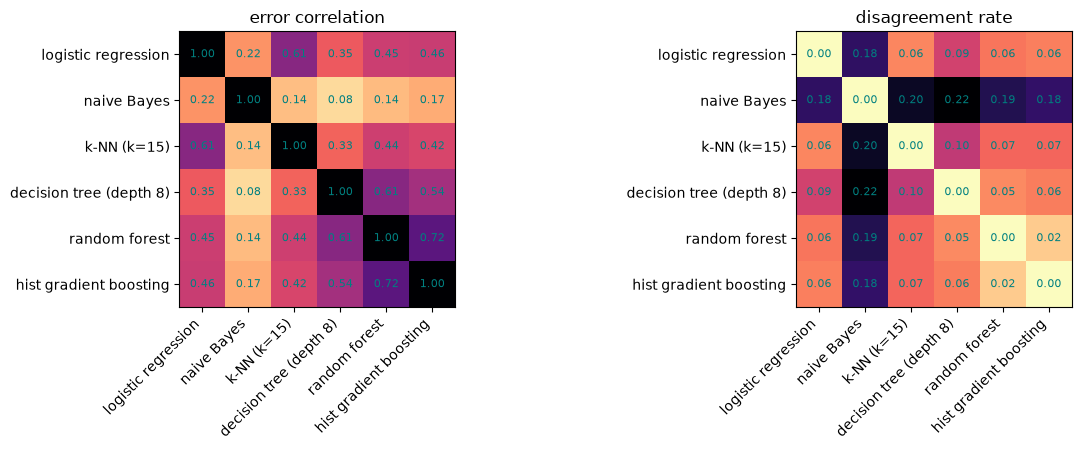

In [4]:
base_models = {
    "logistic regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=5_000)),
    "naive Bayes": GaussianNB(),
    "k-NN (k=15)": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=15)),
    "decision tree (depth 8)": DecisionTreeClassifier(max_depth=8, random_state=SEED),
    "random forest": RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=SEED),
    "hist gradient boosting": HistGradientBoostingClassifier(random_state=SEED),
}
val_pred, val_proba = {}, {}
for name, model in base_models.items():
    model.fit(X_fit, y_fit)
    val_pred[name] = model.predict(X_val)
    val_proba[name] = model.predict_proba(X_val)[:, 1]

errors = pd.DataFrame({name: (pred != y_val).astype(int) for name, pred in val_pred.items()})
base_accuracy = 1 - errors.mean()
print("validation accuracy:\n", base_accuracy.sort_values(ascending=False).round(4).to_string())
error_corr = errors.corr()
disagree = pd.DataFrame({a: {b: np.mean(val_pred[a] != val_pred[b]) for b in val_pred} for a in val_pred})

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for ax, matrix, title in [(axes[0], error_corr, "error correlation"), (axes[1], disagree, "disagreement rate")]:
    ax.imshow(matrix.to_numpy(), cmap="magma_r", vmin=0, vmax=matrix.to_numpy().max())
    ax.set(xticks=range(len(matrix)), yticks=range(len(matrix)), title=title)
    ax.set_xticklabels(matrix.columns, rotation=45, ha="right")
    ax.set_yticklabels(matrix.index)
    for i in range(len(matrix)):
        for j in range(len(matrix)):
            ax.text(j, i, f"{matrix.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8, color="teal")
plt.tight_layout()
plt.show()

Now a direct test of "diversity matters". Instead of hand-picking two groups, we build **every** three-model majority vote from the six models (20 trios). For each trio we record the average error correlation of its members, how much the vote beats the **average** member, and whether it beats the **best** member.

                                                                  trio  mean error corr  mean member acc  vote acc  vote − mean member  vote − best member  if independent (Condorcet)
                   naive Bayes + k-NN (k=15) + decision tree (depth 8)           0.1800           0.8833    0.9380              0.0547              0.0207                      0.9623
        naive Bayes + decision tree (depth 8) + hist gradient boosting           0.2640           0.8982    0.9522              0.0540             -0.0098                      0.9710
                    naive Bayes + k-NN (k=15) + hist gradient boosting           0.2414           0.8996    0.9522              0.0525             -0.0098                      0.9718
                 naive Bayes + decision tree (depth 8) + random forest           0.2760           0.8946    0.9467              0.0522             -0.0043                      0.9690
                             naive Bayes + k-NN (k=15) + random forest           0.24

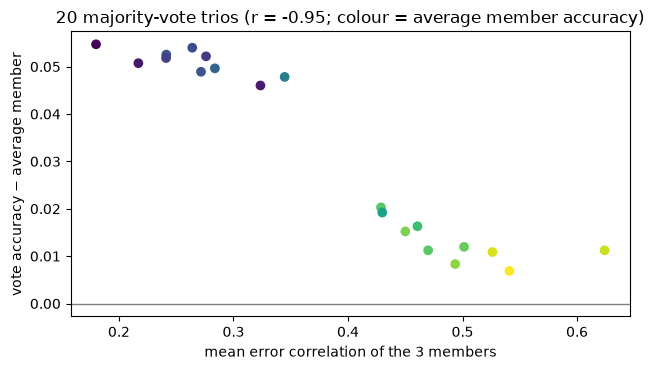


correlation between members' error correlation and the vote's gain over its average member: r = -0.95 → less correlated trios gained more.
4 of 20 trios beat their BEST member; every trio fell short of the independent-errors prediction: True


In [5]:
trio_rows = []
for members in combinations(val_pred, 3):
    votes = np.column_stack([val_pred[m] for m in members])
    vote_accuracy = accuracy_score(y_val, (votes.sum(axis=1) >= 2).astype(int))
    member_accuracy = base_accuracy[list(members)]
    trio_rows.append({
        "trio": " + ".join(members),
        "mean error corr": np.mean([error_corr.loc[a, b] for a, b in combinations(members, 2)]),
        "mean member acc": member_accuracy.mean(), "vote acc": vote_accuracy,
        "vote − mean member": vote_accuracy - member_accuracy.mean(),
        "vote − best member": vote_accuracy - member_accuracy.max(),
        "if independent (Condorcet)": majority_accuracy(member_accuracy.mean(), 3),
    })
trio_table = pd.DataFrame(trio_rows).sort_values("vote − mean member", ascending=False)
print(trio_table.round(4).to_string(index=False))

r_diversity = np.corrcoef(trio_table["mean error corr"], trio_table["vote − mean member"])[0, 1]
beats_best = int((trio_table["vote − best member"] > 0).sum())
fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.scatter(trio_table["mean error corr"], trio_table["vote − mean member"], c=trio_table["mean member acc"], cmap="viridis")
ax.axhline(0, color="gray", lw=1)
ax.set(xlabel="mean error correlation of the 3 members", ylabel="vote accuracy − average member",
       title=f"20 majority-vote trios (r = {r_diversity:+.2f}; colour = average member accuracy)")
plt.tight_layout()
plt.show()

print(f"\ncorrelation between members' error correlation and the vote's gain over its average member: r = {r_diversity:+.2f} → "
      + ("less correlated trios gained more." if r_diversity < 0 else "in this sample, diversity alone did not predict the gain."))
print(f"{beats_best} of 20 trios beat their BEST member; every trio fell short of the independent-errors prediction: "
      f"{bool((trio_table['vote acc'] < trio_table['if independent (Condorcet)']).all())}")

Lessons you can quote in an interview:
1. **Diversity and the gain over the average member:** the printed correlation shows whether less-correlated trios gained more in this run.
2. **Beating the best member is much harder.** In a majority vote, two weaker models can outvote the strongest one; look at how few trios beat their best member. A vote pays off when members are **comparably accurate and make different mistakes**.
3. Correlated errors are the norm (all models struggle on the same hard emails), so real gains are far smaller than the Condorcet curve suggests.

### ✍️ Your Turn

Five **independent** classifiers each have 70% accuracy. What is the accuracy of their majority vote? Compute it with the binomial formula (you may use `math.comb`) and store it in `vote_acc_5`.

In [6]:
vote_acc_5 = None  # TODO
check("vote_acc_5", vote_acc_5, 0.83692, hint="Sum C(5,k) * 0.7**k * 0.3**(5-k) for k = 3, 4, 5.")

⏳ vote_acc_5: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
vote_acc_5 = sum(math.comb(5, k) * 0.7 ** k * 0.3 ** (5 - k) for k in range(3, 6))
check("vote_acc_5", vote_acc_5, 0.83692)
```

0.3087 + 0.3602 + 0.1681 = 0.8369. Independence buys +13.7 points, which real, correlated models never quite get.
</details>

> 💡 **Interview angle:** "Why do ensembles work?" — if members are better than chance and their errors are not perfectly correlated, combining them cancels some errors (Condorcet for votes, $\rho\sigma^2 + \frac{1-\rho}{M}\sigma^2$ for averages). So you want **accurate and diverse** members, and you can measure diversity with error correlation or disagreement on validation data.

## 2. Hard vs Soft Voting and Weights 🟢

| | Hard voting | Soft voting |
|---|---|---|
| Each model gives | a label | class probabilities |
| Combination | (weighted) majority of labels | (weighted) average of probabilities → argmax |
| Needs | `predict` | `predict_proba` on every member |
| Pros | works with any classifier | uses confidence; usually more accurate |
| Cons | ignores confidence; ties with an even number of voters | a badly calibrated member can dominate |

`VotingClassifier` **re-fits clones** of the models you pass in. Weights multiply each member's vote or probabilities.

In [7]:
vote_members = [
    ("lr", make_pipeline(StandardScaler(), LogisticRegression(max_iter=5_000))),
    ("knn", make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=15))),
    ("rf", RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=SEED)),
]
voting_rows = {}
for voting in ["hard", "soft"]:
    ensemble = VotingClassifier(vote_members, voting=voting, n_jobs=None).fit(X_fit, y_fit)
    row = {"val accuracy": ensemble.score(X_val, y_val)}
    if voting == "soft":
        row["val log-loss"] = log_loss(y_val, ensemble.predict_proba(X_val))
        row["val ROC-AUC"] = roc_auc_score(y_val, ensemble.predict_proba(X_val)[:, 1])
    voting_rows[f"{voting} voting (lr + knn + rf)"] = row
for name in ["logistic regression", "k-NN (k=15)", "random forest"]:
    voting_rows[name] = {"val accuracy": base_accuracy[name], "val log-loss": log_loss(y_val, val_proba[name]),
                         "val ROC-AUC": roc_auc_score(y_val, val_proba[name])}
print(pd.DataFrame(voting_rows).T.round(4).to_string())

                             val accuracy  val log-loss  val ROC-AUC
hard voting (lr + knn + rf)        0.9446           NaN          NaN
soft voting (lr + knn + rf)        0.9511        0.1730       0.9879
logistic regression                0.9293        0.1971       0.9772
k-NN (k=15)                        0.9174        0.3294       0.9705
random forest                      0.9511        0.1521       0.9880


**Choosing weights without leaking.** If you try many weight vectors and keep the best **validation** score, that score becomes optimistic. Instead, choose weights with cross-validation on the fit set.

A handy shortcut: collect each member's **out-of-fold probabilities** once with `cross_val_predict`, then score every weight vector on them. Because a soft vote is just a weighted average of probabilities, this gives the same predictions as refitting `VotingClassifier` on every fold, at a fraction of the cost.

In [8]:
folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
oof_proba = {name: cross_val_predict(clone(model), X_fit, y_fit, cv=folds, method="predict_proba")[:, 1]
             for name, model in vote_members}
weight_grid = [(a, b, c) for a in [0, 1, 2, 3] for b in [0, 1, 2, 3] for c in [0, 1, 2, 3] if a + b + c > 0]
weight_scores = {}
for weights in weight_grid:
    blended = np.average(np.column_stack(list(oof_proba.values())), axis=1, weights=weights)
    weight_scores[weights] = log_loss(y_fit, blended)
best_weights = min(weight_scores, key=weight_scores.get)
print(f"searched {len(weight_grid)} weight vectors on out-of-fold probabilities (lr, knn, rf)")
print(f"best weights by OOF log-loss: {best_weights} ({weight_scores[best_weights]:.4f}) vs equal weights "
      f"{weight_scores[(1, 1, 1)]:.4f}")

weighted_vote = VotingClassifier(vote_members, voting="soft", weights=list(best_weights)).fit(X_fit, y_fit)
equal_vote = VotingClassifier(vote_members, voting="soft").fit(X_fit, y_fit)
print(f"validation (touched once for this comparison): weighted accuracy {weighted_vote.score(X_val, y_val):.4f}, "
      f"log-loss {log_loss(y_val, weighted_vote.predict_proba(X_val)):.4f} | equal accuracy {equal_vote.score(X_val, y_val):.4f}, "
      f"log-loss {log_loss(y_val, equal_vote.predict_proba(X_val)):.4f}")
del weighted_vote, equal_vote
gc.collect();

searched 63 weight vectors on out-of-fold probabilities (lr, knn, rf)
best weights by OOF log-loss: (1, 0, 3) (0.1727) vs equal weights 0.1978


validation (touched once for this comparison): weighted accuracy 0.9522, log-loss 0.1526 | equal accuracy 0.9511, log-loss 0.1730


### ✍️ Your Turn

Three models give P(spam) = 0.9, 0.4 and 0.3 for one email (equal weights, threshold 0.5). What does **soft** voting predict, and what does **hard** voting predict? Store `{"soft": ..., "hard": ...}` (1 = spam, 0 = not spam) in `vote_outcomes`.

In [9]:
vote_outcomes = None  # TODO
check("vote_outcomes", vote_outcomes, {"soft": 1, "hard": 0},
      hint="Soft: average the probabilities. Hard: each model votes with its own 0.5 threshold.")

⏳ vote_outcomes: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
p = np.array([0.9, 0.4, 0.3])
vote_outcomes = {"soft": int(p.mean() >= 0.5), "hard": int((p >= 0.5).sum() >= 2)}
check("vote_outcomes", vote_outcomes, {"soft": 1, "hard": 0})
```

The average is 0.533, so soft voting says spam: the first model's strong confidence outweighs two mild "no"s. Hard voting ignores confidence and counts 1 vs 2.
</details>

> 💡 **Interview angle:** "Hard or soft voting?" — soft voting when all members output reasonably **calibrated** probabilities (it uses confidence, usually wins); hard voting when some members can't produce probabilities. Choose weights by cross-validation (e.g. on out-of-fold probabilities), never by peeking at the test set.

## 3. Stacking With Out-of-Fold Predictions 🟡

**Stacking** (Wolpert, 1992) trains a **meta-model** (level 1) to combine the base models (level 0):

```
 fit data ──5-fold cross_val_predict──►  out-of-fold predictions  ──► meta-model (e.g. logistic regression)
    │                                     (one column per base model)
    └──── refit every base model on ALL fit data ───► used at prediction time ──► meta-model ──► prediction
```

Key idea: the meta-model must learn from predictions on rows the base models **did not train on**. Otherwise it learns how the base models behave on their own training data, which is far better than how they behave on new data (Section 4).

`StackingClassifier(estimators, final_estimator=LogisticRegression(), cv=5, stack_method="auto", passthrough=False)`:
- `cv`: folds for the out-of-fold predictions (an integer uses stratified K-fold without shuffling).
- `stack_method="auto"`: uses `predict_proba`, else `decision_function`, else `predict`. For **binary** problems the first probability column is dropped (it's 1 − the second), so each base model contributes one feature.
- `passthrough=True`: the meta-model also sees the original features.
- After fitting: `estimators_` are the base models refit on all data; `final_estimator_` is the meta-model.

In [10]:
stack_members = [
    ("lr", make_pipeline(StandardScaler(), LogisticRegression(max_iter=5_000))),
    ("knn", make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=15))),
    ("rf", RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=SEED)),
    ("hgb", HistGradientBoostingClassifier(random_state=SEED)),
]
start = time.perf_counter()
stack = StackingClassifier(stack_members, final_estimator=LogisticRegression(), cv=folds).fit(X_fit, y_fit)
stack_seconds = time.perf_counter() - start
stack_proba = stack.predict_proba(X_val)[:, 1]
print(f"stacking fit in {stack_seconds:.1f}s (5 out-of-fold fits + 1 full refit per base model)")
print(f"stack       : val accuracy {stack.score(X_val, y_val):.4f} | ROC-AUC {roc_auc_score(y_val, stack_proba):.4f} | "
      f"log-loss {log_loss(y_val, stack_proba):.4f}")
best_base = base_accuracy[["logistic regression", "k-NN (k=15)", "random forest", "hist gradient boosting"]].idxmax()
print(f"best member : {best_base} val accuracy {base_accuracy[best_base]:.4f} | ROC-AUC {roc_auc_score(y_val, val_proba[best_base]):.4f} | "
      f"log-loss {log_loss(y_val, val_proba[best_base]):.4f}")
print("meta-model coefficients (how much it trusts each base model's P(spam)):",
      dict(zip([name for name, _ in stack_members], np.round(stack.final_estimator_.coef_[0], 3))))

stacking fit in 22.5s (5 out-of-fold fits + 1 full refit per base model)
stack       : val accuracy 0.9620 | ROC-AUC 0.9910 | log-loss 0.1198
best member : hist gradient boosting val accuracy 0.9620 | ROC-AUC 0.9927 | log-loss 0.1139
meta-model coefficients (how much it trusts each base model's P(spam)): {'lr': np.float64(0.431), 'knn': np.float64(1.77), 'rf': np.float64(3.956), 'hgb': np.float64(2.731)}


**Verify the mechanism.** If stacking really trains the meta-model on out-of-fold predictions, we can rebuild those features with `cross_val_predict` (same folds) and get the **same** meta-model.

In [11]:
meta_features = np.column_stack([
    cross_val_predict(clone(model), X_fit, y_fit, cv=folds, method="predict_proba")[:, 1] for _, model in stack_members])
manual_meta = LogisticRegression().fit(meta_features, y_fit)
assert np.allclose(manual_meta.coef_, stack.final_estimator_.coef_) and np.allclose(manual_meta.intercept_, stack.final_estimator_.intercept_)
print("✅ meta-model trained on our cross_val_predict features == stack.final_estimator_")
print(f"meta-feature matrix: {meta_features.shape} (rows × base models)")
print(f"stack.transform(X_val) shape {stack.transform(X_val).shape}: at prediction time the features come from the refit estimators_")

passthrough_stack = StackingClassifier(stack_members, final_estimator=LogisticRegression(max_iter=5_000), cv=folds,
                                       passthrough=True).fit(X_fit, y_fit)
print(f"passthrough=True: meta-model sees {passthrough_stack.transform(X_val).shape[1]} features | val accuracy "
      f"{passthrough_stack.score(X_val, y_val):.4f} vs {stack.score(X_val, y_val):.4f} without")
del passthrough_stack

# The same idea in mlxtend (another popular implementation; it also shuffles and seeds its CV folds)
mlx_stack = StackingCVClassifier(classifiers=[clone(model) for _, model in stack_members], meta_classifier=LogisticRegression(),
                                 cv=5, use_probas=True, random_state=SEED).fit(X_fit, y_fit)
print(f"mlxtend StackingCVClassifier (use_probas=True): val accuracy {mlx_stack.score(X_val, y_val):.4f}")
del mlx_stack
gc.collect();

✅ meta-model trained on our cross_val_predict features == stack.final_estimator_
meta-feature matrix: (2760, 4) (rows × base models)
stack.transform(X_val) shape (920, 4): at prediction time the features come from the refit estimators_


passthrough=True: meta-model sees 61 features | val accuracy 0.9609 vs 0.9620 without


mlxtend StackingCVClassifier (use_probas=True): val accuracy 0.9620


**Stacking regressors** work the same way. `StackingRegressor` defaults to `RidgeCV` as the meta-model. Here on California housing (a separate regression split used only in this cell):

In [12]:
housing = fetch_california_housing()
Xh_tr, Xh_te, yh_tr, yh_te = train_test_split(housing.data, housing.target, test_size=0.2, random_state=SEED)
reg_members = [
    ("ridge", make_pipeline(StandardScaler(), Ridge())),
    ("hgb", HistGradientBoostingRegressor(random_state=SEED)),
    ("knn", make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=15))),
]
reg_scores = {name: r2_score(yh_te, clone(model).fit(Xh_tr, yh_tr).predict(Xh_te)) for name, model in reg_members}
stack_reg = StackingRegressor(reg_members).fit(Xh_tr, yh_tr)
reg_scores["StackingRegressor (RidgeCV meta)"] = stack_reg.score(Xh_te, yh_te)
print(pd.Series(reg_scores, name="R²").round(4).to_string())
print("meta weights:", dict(zip([n for n, _ in reg_members], np.round(stack_reg.final_estimator_.coef_, 3))))
del stack_reg, housing
gc.collect();

ridge                               0.5758
hgb                                 0.8347
knn                                 0.6804
StackingRegressor (RidgeCV meta)    0.8355
meta weights: {'ridge': np.float64(-0.045), 'hgb': np.float64(1.005), 'knn': np.float64(0.048)}


### ✍️ Your Turn

How many features does the meta-model see? Use `stack.transform(X_val)` for the fitted `stack` (4 base models, binary task), and a `StackingClassifier` with `passthrough=True` (you may refit one, or reason it out). Store `{"passthrough=False": ..., "passthrough=True": ...}` in `n_meta_features`.

In [13]:
n_meta_features = None  # TODO
check("n_meta_features", n_meta_features, {"passthrough=False": 4, "passthrough=True": 61},
      hint="Binary + predict_proba → one column per base model; passthrough appends the 57 original features.")

⏳ n_meta_features: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
n_meta_features = {"passthrough=False": stack.transform(X_val).shape[1],
                   "passthrough=True": stack.transform(X_val).shape[1] + X_val.shape[1]}
check("n_meta_features", n_meta_features, {"passthrough=False": 4, "passthrough=True": 61})
```

For a **3-class** problem each base model would contribute 3 probability columns (nothing is dropped).
</details>

> 💡 **Interview angle:** "How does stacking avoid leakage?" — the meta-model is trained on **out-of-fold** predictions: each row's base predictions come from models that didn't see that row. At inference, base models refit on all training data feed the meta-model. Keep the meta-model simple (regularized logistic/ridge regression).

## 4. Why In-Sample Stacking Leaks 🔴

The tempting shortcut: fit the base models on the training data, predict **the same** training data, and train the meta-model on those predictions. Models that memorize (a 1-nearest-neighbour, a fully grown tree) look **perfect** in-sample, so the meta-model learns to trust them almost exclusively, and then they disappoint on new data.

We compare three base models, two of which memorize, stacked in-sample vs out-of-fold.

In [14]:
leaky_members = [
    ("1-NN", make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=1))),
    ("deep tree", DecisionTreeClassifier(random_state=SEED)),
    ("logistic regression", make_pipeline(StandardScaler(), LogisticRegression(max_iter=5_000))),
]
names = [name for name, _ in leaky_members]
fitted = [clone(model).fit(X_fit, y_fit) for _, model in leaky_members]

# ❌ in-sample meta-features: predictions on the very rows the base models trained on
in_sample_features = np.column_stack([model.predict_proba(X_fit)[:, 1] for model in fitted])
leaky_meta = LogisticRegression().fit(in_sample_features, y_fit)
val_features = np.column_stack([model.predict_proba(X_val)[:, 1] for model in fitted])
leaky_accuracy = accuracy_score(y_val, leaky_meta.predict(val_features))
leaky_proba = leaky_meta.predict_proba(val_features)[:, 1]

# ✅ out-of-fold meta-features
oof_stack = StackingClassifier(leaky_members, final_estimator=LogisticRegression(), cv=folds).fit(X_fit, y_fit)

print("in-sample training accuracy of each base model:",
      {n: round(accuracy_score(y_fit, (f >= 0.5).astype(int)), 4) for n, f in zip(names, in_sample_features.T)})
print("validation accuracy of each base model       :",
      {n: round(accuracy_score(y_val, m.predict(X_val)), 4) for n, m in zip(names, fitted)})
print("\nmeta-model coefficients:")
print(pd.DataFrame({"❌ in-sample stack": leaky_meta.coef_[0], "✅ out-of-fold stack": oof_stack.final_estimator_.coef_[0]},
                   index=names).round(3).to_string())
oof_proba_val = oof_stack.predict_proba(X_val)[:, 1]
leak_comparison = pd.DataFrame({
    "❌ in-sample stack": {"val accuracy": leaky_accuracy, "val ROC-AUC": roc_auc_score(y_val, leaky_proba),
                          "val log-loss": log_loss(y_val, leaky_proba)},
    "✅ out-of-fold stack": {"val accuracy": oof_stack.score(X_val, y_val), "val ROC-AUC": roc_auc_score(y_val, oof_proba_val),
                            "val log-loss": log_loss(y_val, oof_proba_val)}}).T
print()
print(leak_comparison.round(4).to_string())
leaky_top = [n for n, c in zip(names, leaky_meta.coef_[0]) if np.isclose(c, leaky_meta.coef_[0].max())]
honest_top = names[int(np.argmax(oof_stack.final_estimator_.coef_[0]))]
print(f"\n→ In-sample, the largest meta weight went to {' and '.join(leaky_top)} (perfect on data they memorized); "
      f"out-of-fold, it went to {honest_top}.")
worse = [metric for metric, higher_is_better in [("val accuracy", True), ("val ROC-AUC", True), ("val log-loss", False)]
         if (leak_comparison.loc["❌ in-sample stack", metric] < leak_comparison.loc["✅ out-of-fold stack", metric]) == higher_is_better]
print(f"→ The in-sample stack is worse on: {', '.join(worse) if worse else 'none of the three metrics in this run'}.")
del oof_stack, fitted
gc.collect();

in-sample training accuracy of each base model: {'1-NN': 1.0, 'deep tree': 1.0, 'logistic regression': 0.9236}
validation accuracy of each base model       : {'1-NN': 0.9087, 'deep tree': 0.9011, 'logistic regression': 0.9293}

meta-model coefficients:
                     ❌ in-sample stack  ✅ out-of-fold stack
1-NN                             4.962                1.844
deep tree                        4.962                2.306
logistic regression              2.110                3.803



                     val accuracy  val ROC-AUC  val log-loss
❌ in-sample stack          0.9511       0.9820        0.2245
✅ out-of-fold stack        0.9522       0.9832        0.1586

→ In-sample, the largest meta weight went to 1-NN and deep tree (perfect on data they memorized); out-of-fold, it went to logistic regression.
→ The in-sample stack is worse on: val accuracy, val ROC-AUC, val log-loss.


Out-of-fold predictions reveal that 1-NN and the deep tree are no better than logistic regression on unseen rows, so the honest meta-model shifts its trust. (In-sample, 1-NN and the tree both predict the training labels perfectly, so their meta features are identical and they share the weight.) How much the leak costs in scores depends on the data; compare the metrics printed above. The wrong weights are the reliable symptom. The same leak appears whenever any "second-level" model (a calibrator, a threshold, a blender) is fit on predictions from models trained on the same rows.

> 💡 **Interview angle:** "Why can't you train the stacker on in-sample predictions?" — base models, especially flexible ones, are overconfident on their own training rows, so the meta-model learns to trust whoever memorized most. It's target leakage at the second level. Use out-of-fold predictions (K-fold) or a separate holdout (blending).

## 5. Blending: Stacking With a Holdout Set 🟡

**Blending** is the simpler cousin of stacking, popular in competitions:
1. Split the training data into a **base** part and a **blend holdout**.
2. Fit the base models on the base part only.
3. Fit the meta-model on the base models' predictions for the holdout.

| | Stacking (K-fold OOF) | Blending (holdout) |
|---|---|---|
| Data for base models | all rows (refit) | base part only |
| Data for meta-model | all rows (out-of-fold) | holdout only |
| Cost | (K+1) fits per base model | 1 fit per base model |
| Leakage risk | low | low, if the holdout is truly separate |
| Weakness | slower | wastes data at both levels, noisier meta-model |

In scikit-learn ≥ 1.6, wrap already-fitted models in **`FrozenEstimator`** so `StackingClassifier` uses them as they are, without refitting.

In [15]:
X_base, X_blend, y_base, y_blend = train_test_split(X_fit, y_fit, test_size=0.3, stratify=y_fit, random_state=SEED)
base_fitted = [(name, clone(model).fit(X_base, y_base)) for name, model in stack_members]

# Manual blend
blend_features = np.column_stack([model.predict_proba(X_blend)[:, 1] for _, model in base_fitted])
manual_blender = LogisticRegression().fit(blend_features, y_blend)
val_blend_features = np.column_stack([model.predict_proba(X_val)[:, 1] for _, model in base_fitted])
manual_blend_accuracy = accuracy_score(y_val, manual_blender.predict(val_blend_features))

# The same blend with FrozenEstimator + StackingClassifier (fit on the holdout only)
frozen_blend = StackingClassifier([(name, FrozenEstimator(model)) for name, model in base_fitted],
                                  final_estimator=LogisticRegression()).fit(X_blend, y_blend)
assert np.allclose(frozen_blend.final_estimator_.coef_, manual_blender.coef_)
assert np.array_equal(frozen_blend.predict(X_val), manual_blender.predict(val_blend_features))
print("✅ StackingClassifier over FrozenEstimator models == manual blend (same meta-model, same predictions)")
print(f"blend base models trained on {len(X_base):,} rows, meta-model on {len(X_blend):,} rows")
print(f"validation accuracy: blending {manual_blend_accuracy:.4f} | K-fold stacking {stack.score(X_val, y_val):.4f}")
del base_fitted, frozen_blend
gc.collect();

✅ StackingClassifier over FrozenEstimator models == manual blend (same meta-model, same predictions)
blend base models trained on 1,932 rows, meta-model on 828 rows
validation accuracy: blending 0.9565 | K-fold stacking 0.9620


Why does `FrozenEstimator` give the holdout predictions even though the stack uses 5-fold `cross_val_predict` internally? A frozen model ignores `fit`, so every fold just calls the same pre-fitted model. That's exactly "predict the holdout with models trained elsewhere". Don't freeze models trained on the **same** rows you fit the stack on: that's the in-sample leak from Section 4.

> 💡 **Interview angle:** "Stacking vs blending?" — both train a meta-model on predictions for rows the base models didn't see. Stacking uses K-fold out-of-fold predictions (uses all data, K+1 fits); blending uses one holdout (cheaper, simpler to parallelize across a team, but less data for each level).

## 6. AdaBoost: The SAMME Algorithm 🟡

**AdaBoost** (Freund & Schapire, 1997) builds a strong classifier from **weak learners** that are only slightly better than guessing, usually **decision stumps** (trees with one split). scikit-learn implements the multi-class version **SAMME** (Zhu, Zou, Rosset & Hastie, 2009). With $n$ rows and $K$ classes:

1. Start with equal sample weights $w_i = 1/n$.
2. For $m = 1, \dots, M$:
   - fit a weak learner $h_m$ using the weights (`fit(X, y, sample_weight=w)`),
   - weighted error: $\text{err}_m = \dfrac{\sum_i w_i\, \mathbb{1}[h_m(x_i) \ne y_i]}{\sum_i w_i}$,
   - learner weight ("amount of say"): $\alpha_m = \eta\left[\log\dfrac{1-\text{err}_m}{\text{err}_m} + \log(K-1)\right]$,
   - **up-weight the mistakes:** $w_i \leftarrow w_i \cdot \exp\big(\alpha_m\, \mathbb{1}[h_m(x_i) \ne y_i]\big)$, then renormalize.
3. Predict the class with the largest total say: $\hat y(x) = \arg\max_k \sum_m \alpha_m\, \mathbb{1}[h_m(x) = k]$.

Details from the installed scikit-learn source (all reproduced in 🔧 Build It From Scratch):
- A learner must beat random guessing: if $\text{err}_m \ge 1 - 1/K$, it is discarded and boosting stops. If $\text{err}_m = 0$, boosting stops too (that learner gets weight 1).
- For $K = 2$, $\log(K-1) = 0$, so $\alpha_m = \eta\log\frac{1-\text{err}}{\text{err}}$. That's **twice** the classic $\frac12\log\frac{1-\text{err}}{\text{err}}$ from the original paper, which changes neither the predictions nor the normalized weights (Section 7).
- `learning_rate` ($\eta$) shrinks every $\alpha_m$. The old `algorithm="SAMME.R"` option was removed; SAMME is the only algorithm.

Let's run five rounds **by hand** on the breast cancer data and watch the weights.

                      stump question  misclassified rows  weighted error  alpha (say)  largest weight × n
round                                                                                                    
1             worst radius <= 16.795                  33          0.0775       2.4773              6.4545
2      worst concave points <= 0.136                  35          0.1278       1.9205             25.2516
3            worst texture <= 23.350                 131          0.1364       1.8455             14.6201
4               area error <= 31.285                  55          0.2312       1.2018             31.6234
5           worst concavity <= 0.205                  78          0.2175       1.2803             21.8575

✅ after every update the misclassified rows hold exactly 50% of the total weight
after  1 rounds: the heaviest 5% of rows hold 31.8% of the weight
after  5 rounds: the heaviest 5% of rows hold 52.1% of the weight
after 20 rounds: the heaviest 5% of rows hol

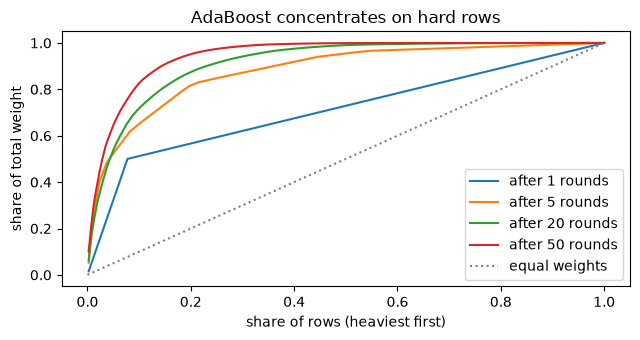

In [16]:
cancer = load_breast_cancer()
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(cancer.data, cancer.target, test_size=0.25, stratify=cancer.target,
                                              random_state=SEED)
n_rows = len(Xc_tr)
weights = np.full(n_rows, 1 / n_rows)
round_rows, snapshots = [], {}
for m in range(1, 51):
    stump = DecisionTreeClassifier(max_depth=1, random_state=SEED).fit(Xc_tr, yc_tr, sample_weight=weights)
    wrong = stump.predict(Xc_tr) != yc_tr
    err = weights[wrong].sum() / weights.sum()
    alpha = np.log((1 - err) / err) + np.log(2 - 1)                  # K = 2 classes, learning_rate = 1
    weights = weights * np.exp(alpha * wrong)
    weights = weights / weights.sum()
    assert np.isclose(weights[wrong].sum(), 0.5)                     # after each update, mistakes hold half the weight
    if m <= 5:
        round_rows.append({"round": m, "stump question": f"{cancer.feature_names[stump.tree_.feature[0]]} <= {stump.tree_.threshold[0]:.3f}",
                           "misclassified rows": int(wrong.sum()), "weighted error": err, "alpha (say)": alpha,
                           "largest weight × n": weights.max() * n_rows})
    if m in (1, 5, 20, 50):
        snapshots[m] = weights.copy()
print(pd.DataFrame(round_rows).set_index("round").round(4).to_string())
print("\n✅ after every update the misclassified rows hold exactly 50% of the total weight")
for m, w in snapshots.items():
    top = np.sort(w)[::-1][: n_rows // 20].sum()
    print(f"after {m:>2} rounds: the heaviest 5% of rows hold {top:.1%} of the weight")

fig, ax = plt.subplots(figsize=(6.5, 3.5))
for m, w in snapshots.items():
    ax.plot(np.arange(1, n_rows + 1) / n_rows, np.sort(w)[::-1].cumsum(), label=f"after {m} rounds")
ax.plot([0, 1], [0, 1], color="gray", ls=":", label="equal weights")
ax.set(xlabel="share of rows (heaviest first)", ylabel="share of total weight", title="AdaBoost concentrates on hard rows")
ax.legend()
plt.tight_layout()
plt.show()

Why exactly 50%? After the update the mistakes weigh $\text{err}\cdot\frac{1-\text{err}}{\text{err}} = 1-\text{err}$ and the correct rows also weigh $1-\text{err}$. So the **previous** stump is no better than a coin flip on the new weights, which forces the next stump to find something new. Over many rounds the weight piles onto a small set of hard rows. That's powerful when those rows are informative, and dangerous when they're mislabeled (Section 10).

### ✍️ Your Turn

A 3-class problem, a stump with weighted error 0.2, and `learning_rate=0.5`. What learner weight $\alpha$ does SAMME assign? Store it in `samme_alpha_ex`.

In [17]:
samme_alpha_ex = None  # TODO
check("samme_alpha_ex", samme_alpha_ex, 1.0397208, hint="learning_rate * (log((1 - err) / err) + log(K - 1))")

⏳ samme_alpha_ex: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
err, K, lr = 0.2, 3, 0.5
samme_alpha_ex = lr * (np.log((1 - err) / err) + np.log(K - 1))
check("samme_alpha_ex", samme_alpha_ex, 1.0397208)
```

$0.5(\log 4 + \log 2) = 0.5\log 8$. The $\log(K-1)$ term lets a 3-class learner with error up to $1 - 1/3$ still get positive say, because random guessing is only 33% accurate.
</details>

> 💡 **Interview angle:** "Walk me through AdaBoost." — equal weights; fit a stump on weighted data; compute its weighted error; give it say $\alpha = \log\frac{1-\text{err}}{\text{err}}$ (+ $\log(K-1)$ for SAMME); multiply the weights of misclassified rows by $e^{\alpha}$ and renormalize; repeat; predict by weighted vote. Contrast with gradient boosting: AdaBoost **reweights rows**, gradient boosting **fits residuals**.

## 7. AdaBoost as Exponential-Loss Minimization 🔴

Friedman, Hastie & Tibshirani (2000) showed AdaBoost is **forward stagewise additive modelling** with the **exponential loss**. Use labels $y \in \{-1, +1\}$, stumps $h(x) \in \{-1, +1\}$, and a model $F_{m-1}$ built so far. We add $\beta h$ and minimize

$$L(\beta, h) = \sum_i e^{-y_i\,[F_{m-1}(x_i) + \beta h(x_i)]} = \sum_i w_i\, e^{-\beta\, y_i h(x_i)}, \qquad w_i = e^{-y_i F_{m-1}(x_i)}$$

The $w_i$ are exactly AdaBoost's sample weights: rows with a negative **margin** $y_i F(x_i)$ (wrong so far) weigh the most. Split the sum into correct ($y h = 1$) and wrong ($y h = -1$) rows:

$$L = e^{-\beta}\sum_{\text{correct}} w_i + e^{\beta}\sum_{\text{wrong}} w_i = \left(e^{\beta}-e^{-\beta}\right)\sum_{\text{wrong}} w_i + e^{-\beta}\sum_i w_i$$

- **Best $h$:** for any $\beta > 0$, minimize the weighted number of mistakes → fit the stump on weighted data.
- **Best $\beta$:** set $\partial L/\partial\beta = 0$ → $\beta^* = \frac12 \log\frac{1-\text{err}}{\text{err}}$.
- **Weight update:** $w_i \leftarrow w_i e^{-\beta^* y_i h(x_i)}$, which after renormalizing equals multiplying the mistakes by $e^{2\beta^*}$. So SAMME's $\alpha = 2\beta^*$ (for $K=2$, $\eta = 1$).
- **What $F$ estimates:** the minimizer of the expected exponential loss is $F^*(x) = \frac12\log\frac{P(y=1\mid x)}{P(y=-1\mid x)}$, half the log-odds. That's why AdaBoost can output probabilities, and why it's gradient boosting with an exponential loss (`GradientBoostingClassifier(loss="exponential")`).

First, the losses side by side as a function of the margin $y F(x)$:

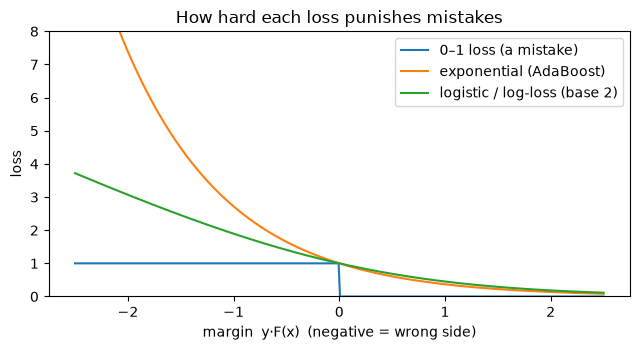

margin -1: exponential loss    2.72 | log-loss  1.89
margin -2: exponential loss    7.39 | log-loss  3.07
margin -4: exponential loss   54.60 | log-loss  5.80


In [18]:
margin = np.linspace(-2.5, 2.5, 400)
fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.plot(margin, (margin <= 0).astype(float), label="0–1 loss (a mistake)")
ax.plot(margin, np.exp(-margin), label="exponential (AdaBoost)")
ax.plot(margin, np.log2(1 + np.exp(-margin)), label="logistic / log-loss (base 2)")
ax.set(xlabel="margin  y·F(x)  (negative = wrong side)", ylabel="loss", ylim=(0, 8), title="How hard each loss punishes mistakes")
ax.legend()
plt.tight_layout()
plt.show()
for m_value in [-1, -2, -4]:
    print(f"margin {m_value:>2}: exponential loss {np.exp(-m_value):7.2f} | log-loss {np.log2(1 + np.exp(-m_value)):5.2f}")

The exponential loss grows **exponentially** for badly wrong rows, while log-loss grows only linearly. A mislabeled row sits at a large negative margin forever, so AdaBoost keeps pouring weight into it.

Now let's **verify the derivation** against a real `AdaBoostClassifier` on Spambase: at each round, rebuild the weights from the exponential loss, find $\beta^*$ with a numerical optimizer, and compare with scikit-learn.

In [19]:
ada_exp = AdaBoostClassifier(n_estimators=30, learning_rate=1.0, random_state=SEED).fit(X_fit, y_fit)
y_pm = np.where(y_fit == 1, 1, -1)
F = np.zeros(len(y_fit))
exp_rows = []
for m, (alpha, stump) in enumerate(zip(ada_exp.estimator_weights_, ada_exp.estimators_), start=1):
    w = np.exp(-y_pm * F)                                              # weights = each row's exponential loss so far
    h = np.where(stump.predict(X_fit) == 1, 1, -1)
    beta_star = minimize_scalar(lambda b: np.sum(w * np.exp(-b * y_pm * h)), bounds=(0, 20), method="bounded",
                                options={"xatol": 1e-10}).x
    weighted_err = np.sum(w * (h != y_pm)) / w.sum()
    F += 0.5 * alpha * h                                               # β = α / 2
    exp_rows.append({"round": m, "weighted error": weighted_err, "sklearn error": ada_exp.estimator_errors_[m - 1],
                     "β* numeric": beta_star, "½·log((1−err)/err)": 0.5 * np.log((1 - weighted_err) / weighted_err),
                     "sklearn α / 2": alpha / 2, "train exp. loss": np.mean(np.exp(-y_pm * F)),
                     "train error": np.mean(np.sign(F) != y_pm)})
exp_table = pd.DataFrame(exp_rows).set_index("round")
assert np.allclose(exp_table["weighted error"], exp_table["sklearn error"], rtol=1e-6)
assert np.allclose(exp_table["β* numeric"], exp_table["sklearn α / 2"], rtol=1e-5)
assert np.allclose(exp_table["β* numeric"], exp_table["½·log((1−err)/err)"], rtol=1e-5)
assert (exp_table["train exp. loss"] >= exp_table["train error"]).all()
assert (np.diff(exp_table["train exp. loss"]) < 0).all()
print("✅ weights from e^(−yF) reproduce sklearn's weighted errors; numeric β* = ½·log((1−err)/err) = sklearn α/2")
print("✅ training exponential loss falls every round and always upper-bounds the training error")
print(exp_table.iloc[[0, 1, 2, 9, 19, 29]].round(5).to_string())

✅ weights from e^(−yF) reproduce sklearn's weighted errors; numeric β* = ½·log((1−err)/err) = sklearn α/2
✅ training exponential loss falls every round and always upper-bounds the training error
       weighted error  sklearn error  β* numeric  ½·log((1−err)/err)  sklearn α / 2  train exp. loss  train error
round                                                                                                            
1              0.1967         0.1967      0.7034              0.7034         0.7034           0.7951       0.1967
2              0.2459         0.2459      0.5604              0.5604         0.5604           0.6847       0.1967
3              0.2847         0.2847      0.4607              0.4607         0.4607           0.6179       0.1496
10             0.4124         0.4124      0.1771              0.1771         0.1771           0.4425       0.0841
20             0.4434         0.4434      0.1137              0.1137         0.1137           0.3941       0.0746
30     

### ✍️ Your Turn

In the exponential-loss view, what is the optimal step $\beta^*$ when the weighted error is 0.25? Store it in `beta_star_ex`.

In [20]:
beta_star_ex = None  # TODO
check("beta_star_ex", beta_star_ex, 0.5493061, hint="0.5 * log((1 - err) / err)")

⏳ beta_star_ex: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
err = 0.25
beta_star_ex = 0.5 * np.log((1 - err) / err)
check("beta_star_ex", beta_star_ex, 0.5493061)
print("SAMME's alpha for K=2 would be", 2 * beta_star_ex)
```
</details>

> 💡 **Interview angle:** "What loss does AdaBoost minimize?" — the exponential loss $e^{-yF(x)}$, by forward stagewise additive modelling. The sample weights are each row's current loss, the stump minimizes weighted error, and $\beta^* = \frac12\log\frac{1-\text{err}}{\text{err}}$ is the exact line search. Its population minimizer is half the log-odds, and exponential growth for negative margins explains its noise sensitivity.

## 8. Decision Stumps as Weak Learners 🟢

A **weak learner** only needs to be a bit better than random guessing on the weighted data. A **decision stump** is the classic choice: one feature, one threshold, two leaves. It's fast, has high bias and low variance, and boosting removes the bias.

one stump: 'char_freq_%24 <= 0.027' → validation accuracy 0.7859


                         estimators kept  train accuracy  val accuracy   fit s
AdaBoost, depth-1 trees            200.0          0.9478        0.9413  0.4476
AdaBoost, depth-2 trees            200.0          0.9670        0.9478  0.7528
AdaBoost, depth-3 trees            200.0          0.9909        0.9543  1.0618

the first 8 stumps:
                                   question  weighted error   alpha
round                                                             
1                   char_freq_%24 <= 0.027          0.1967  1.4068
2                   char_freq_%21 <= 0.080          0.2459  1.1208
3                    word_freq_hp <= 0.120          0.2847  0.9215
4                word_freq_remove <= 0.010          0.2880  0.9050
5                word_freq_george <= 0.005          0.3367  0.6780
6      capital_run_length_average <= 2.216          0.3291  0.7121
7                  word_freq_free <= 0.025          0.3235  0.7377
8                    word_freq_re <= 0.475          0.3900 

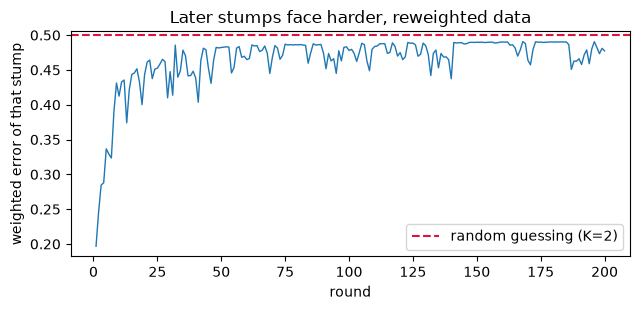

In [21]:
single_stump = DecisionTreeClassifier(max_depth=1, random_state=SEED).fit(X_fit, y_fit)
print(f"one stump: '{spam_features[single_stump.tree_.feature[0]]} <= {single_stump.tree_.threshold[0]:.3f}' → "
      f"validation accuracy {single_stump.score(X_val, y_val):.4f}")

depth_rows = {}
for depth in [1, 2, 3]:
    start = time.perf_counter()
    model = AdaBoostClassifier(DecisionTreeClassifier(max_depth=depth), n_estimators=200, random_state=SEED).fit(X_fit, y_fit)
    depth_rows[f"AdaBoost, depth-{depth} trees"] = {"estimators kept": len(model.estimators_),
                                                    "train accuracy": model.score(X_fit, y_fit),
                                                    "val accuracy": model.score(X_val, y_val),
                                                    "fit s": time.perf_counter() - start}
    if depth == 1:
        stump_model = model
print(pd.DataFrame(depth_rows).T.round(4).to_string())

first_stumps = pd.DataFrame({
    "question": [f"{spam_features[s.tree_.feature[0]]} <= {s.tree_.threshold[0]:.3f}" for s in stump_model.estimators_[:8]],
    "weighted error": stump_model.estimator_errors_[:8], "alpha": stump_model.estimator_weights_[:8]},
    index=pd.RangeIndex(1, 9, name="round"))
print("\nthe first 8 stumps:\n", first_stumps.round(4).to_string())
say_by_feature = pd.Series(stump_model.estimator_weights_, index=[spam_features[s.tree_.feature[0]] for s in stump_model.estimators_]
                           ).groupby(level=0).sum().sort_values(ascending=False)
print(f"\n{say_by_feature.size} distinct features used by 200 stumps; top 5 by total say:\n{say_by_feature.head(5).round(3).to_string()}")

fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.plot(np.arange(1, 201), stump_model.estimator_errors_, lw=1)
ax.axhline(0.5, color="crimson", ls="--", label="random guessing (K=2)")
ax.set(xlabel="round", ylabel="weighted error of that stump", title="Later stumps face harder, reweighted data")
ax.legend()
plt.tight_layout()
plt.show()
del single_stump

- One stump is weak, but 200 boosted stumps form a strong classifier: an **additive model** of one-feature rules, which is also fairly interpretable.
- Each new stump's weighted error creeps towards 0.5: the reweighting keeps making the data harder.
- Deeper base trees fit the training data faster. They can help on problems with feature interactions, but they overfit sooner and stop being "weak". A fully grown tree gets zero training error in round 1 and boosting stops immediately (⚠️ Pitfall 2).

### ✍️ Your Turn

For a **4-class** problem, what is the largest weighted error a SAMME learner may have before scikit-learn discards it and stops boosting? Store it in `max_error_k4`.

In [22]:
max_error_k4 = None  # TODO
check("max_error_k4", max_error_k4, 0.75, hint="A learner must beat random guessing: error < 1 - 1/K.")

⏳ max_error_k4: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
K = 4
max_error_k4 = 1 - 1 / K
check("max_error_k4", max_error_k4, 0.75)
```

At exactly that error, $\log\frac{1-\text{err}}{\text{err}} + \log(K-1) = \log\frac{1/4}{3/4} + \log 3 = 0$: the learner would get zero say.
</details>

> 💡 **Interview angle:** "Why stumps?" — they're the simplest learners that beat chance: fast to fit on weighted data, low variance, and boosting reduces their bias. An additive model of stumps captures no feature interactions; allow depth 2–3 if interactions matter. Deep trees defeat the purpose (zero training error → boosting stops).

## 9. Learning Rate vs Number of Estimators 🟡

`learning_rate` ($\eta$) multiplies every $\alpha_m$, so each stump moves the model less and the sample weights change more slowly. Smaller $\eta$ needs more stumps but often generalizes better. `staged_score` gives the score after every round from a single fit.

               best n_estimators  best val acc  val acc @600  train acc @600  seconds
learning_rate                                                                        
0.05                         293        0.9359        0.9348          0.9333   1.5231
0.20                         479        0.9402        0.9391          0.9428   1.5406
0.50                         554        0.9457        0.9446          0.9486   1.5150
1.00                         574        0.9489        0.9478          0.9533   1.5355
1.50                         515        0.9489        0.9457          0.9685   1.5741


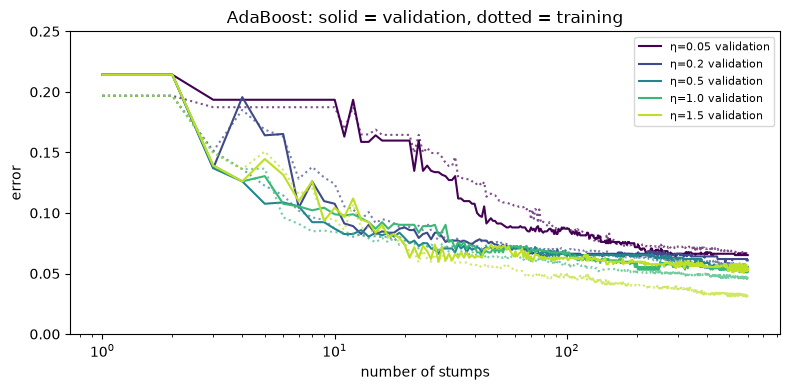

after 600 stumps, training accuracy ranges from 0.9333 (η=0.05) to 0.9685 (η=1.5).
best validation accuracy: η=1.0 (0.9489) | η=0.05 reached only 0.9359 within 600 stumps
η=1.5: training accuracy 0.9685 vs validation 0.9457 at 600 stumps (gap 0.0228)


In [23]:
lr_curves, lr_rows = {}, []
for lr in [0.05, 0.2, 0.5, 1.0, 1.5]:
    start = time.perf_counter()
    model = AdaBoostClassifier(n_estimators=600, learning_rate=lr, random_state=SEED).fit(X_fit, y_fit)
    train_curve = np.fromiter(model.staged_score(X_fit, y_fit), dtype=float)
    val_curve = np.fromiter(model.staged_score(X_val, y_val), dtype=float)
    lr_curves[lr] = (train_curve, val_curve)
    best = int(np.argmax(val_curve))
    lr_rows.append({"learning_rate": lr, "best n_estimators": best + 1, "best val acc": val_curve[best],
                    "val acc @600": val_curve[-1], "train acc @600": train_curve[-1], "seconds": time.perf_counter() - start})
lr_table = pd.DataFrame(lr_rows).set_index("learning_rate")
print(lr_table.round(4).to_string())

fig, ax = plt.subplots(figsize=(8, 4))
for (lr, (train_curve, val_curve)), color in zip(lr_curves.items(), plt.cm.viridis(np.linspace(0, 0.9, len(lr_curves)))):
    rounds = np.arange(1, len(val_curve) + 1)
    ax.plot(rounds, 1 - val_curve, color=color, label=f"η={lr} validation")
    ax.plot(rounds, 1 - train_curve, color=color, ls=":", alpha=0.7)
ax.set(xscale="log", xlabel="number of stumps", ylabel="error", ylim=(0, 0.25),
       title="AdaBoost: solid = validation, dotted = training")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

least_fit = lr_table["train acc @600"].idxmin()
most_fit = lr_table["train acc @600"].idxmax()
print(f"after 600 stumps, training accuracy ranges from {lr_table.loc[least_fit, 'train acc @600']:.4f} (η={least_fit}) "
      f"to {lr_table.loc[most_fit, 'train acc @600']:.4f} (η={most_fit}).")
print(f"best validation accuracy: η={lr_table['best val acc'].idxmax()} ({lr_table['best val acc'].max():.4f}) | "
      f"η={least_fit} reached only {lr_table.loc[least_fit, 'best val acc']:.4f} within 600 stumps")
print(f"η={most_fit}: training accuracy {lr_table.loc[most_fit, 'train acc @600']:.4f} vs validation {lr_table.loc[most_fit, 'val acc @600']:.4f} "
      f"at 600 stumps (gap {lr_table.loc[most_fit, 'train acc @600'] - lr_table.loc[most_fit, 'val acc @600']:.4f})")
del lr_curves

- **Trade-off:** a small $\eta$ moves slowly. With a fixed budget of 600 stumps, the smallest rates are still **underfitting**: their training accuracy is the lowest, and they would need many more rounds to catch up. The rule of thumb "smaller learning rate generalizes better" only holds if you give it enough rounds.
- A large $\eta$ fits the training data fastest and opens the widest train–validation gap.
- Training error keeps falling after validation error has flattened, so pick `n_estimators` on validation or CV. `staged_score` makes that one fit per learning rate.
- AdaBoost has no built-in early stopping, unlike `HistGradientBoostingClassifier`.

> 💡 **Interview angle:** "How do `learning_rate` and `n_estimators` interact in AdaBoost?" — shrinkage scales each learner's say, so halving η roughly needs twice the learners. A smaller η can generalize a little better **if** you give it enough rounds; with a fixed round budget a larger η may win, as it did here. Tune them together and choose the count with `staged_score` on validation data.

## 10. Sensitivity to Label Noise and Outliers 🔴

Section 7 predicted it: a row on the wrong side of the boundary gets weight $e^{-yF}$, which grows exponentially as the model becomes more sure it's "wrong". A **mislabeled** email looks exactly like that.

**Experiment.** Flip a random fraction of the **fit** labels (0%, 10%, 20%, 30%), train five models, and score them on the **clean** validation labels. We repeat with 2 random seeds and average. To separate the loss from the weak learner, we compare:
- AdaBoost with **stumps** and with **depth-2 trees** (300 rounds, `learning_rate=1`),
- gradient boosting with the **same depth-2 trees**, once with **log-loss** and once with the **exponential loss** (300 rounds, `learning_rate=0.1`),
- a random forest (bagging) as the reference.

Then an **outlier-like** noise: flip the 5% of rows that a logistic regression (out-of-fold) is *most confident* about, the rows a model "can't" get right.

trained 45 models in 35.0s
noise                                    random 0%  random 10%  random 20%  random 30%  5% confident flips  drop 0% → 30%  drop from 5% confident flips
model                                                                                                                                                  
AdaBoost, stumps                            0.9435      0.9446      0.9304      0.8957              0.9228         0.0478                        0.0207
AdaBoost, depth-2 trees                     0.9467      0.9321      0.9098      0.8511              0.9207         0.0957                        0.0261
gradient boosting, depth 2, log-loss        0.9489      0.9370      0.9212      0.8799              0.9054         0.0690                        0.0435
gradient boosting, depth 2, exponential     0.9500      0.9435      0.9277      0.8815              0.9283         0.0685                        0.0217
random forest                               0.9435      0.944

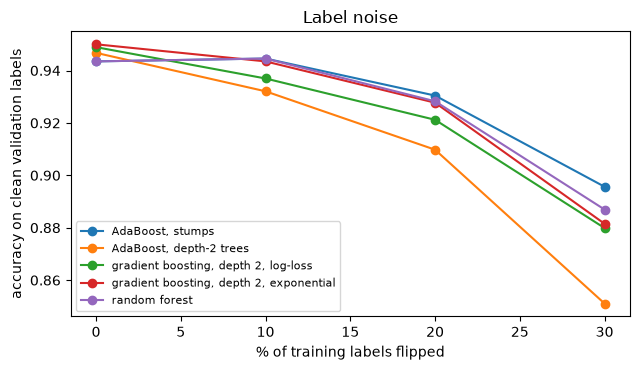

largest accuracy drop at 30% random noise: AdaBoost, depth-2 trees (0.0957); smallest: AdaBoost, stumps (0.0478)
weak-learner capacity: AdaBoost with depth-2 trees dropped 0.0957 vs 0.0478 with stumps
same depth-2 trees: AdaBoost 0.0957 | gradient boosting exponential 0.0685 | log-loss 0.0690 | random forest 0.0565
5% confident (outlier-like) flips hurt gradient boosting, depth 2, log-loss most (0.0435) and random forest least (0.0120)


In [24]:
noise_models = {
    "AdaBoost, stumps": AdaBoostClassifier(n_estimators=300, random_state=SEED),
    "AdaBoost, depth-2 trees": AdaBoostClassifier(DecisionTreeClassifier(max_depth=2), n_estimators=300, random_state=SEED),
    "gradient boosting, depth 2, log-loss": GradientBoostingClassifier(loss="log_loss", max_depth=2, n_estimators=300,
                                                                        learning_rate=0.1, random_state=SEED),
    "gradient boosting, depth 2, exponential": GradientBoostingClassifier(loss="exponential", max_depth=2, n_estimators=300,
                                                                           learning_rate=0.1, random_state=SEED),
    "random forest": RandomForestClassifier(n_estimators=300, min_samples_leaf=3, n_jobs=-1, random_state=SEED),
}
noise_rows = []
start = time.perf_counter()
for rate in [0.0, 0.1, 0.2, 0.3]:
    for repeat in range(2):
        flip = np.random.default_rng(100 + repeat).random(len(y_fit)) < rate
        y_noisy = np.where(flip, 1 - y_fit, y_fit)
        for name, model in noise_models.items():
            noise_rows.append({"noise": f"random {rate:.0%}", "rate": rate, "model": name,
                               "val accuracy": clone(model).fit(X_fit, y_noisy).score(X_val, y_val)})

lr_oof = cross_val_predict(make_pipeline(StandardScaler(), LogisticRegression(max_iter=5_000)), X_fit, y_fit, cv=folds,
                           method="predict_proba")[:, 1]
confident = np.argsort(-np.abs(lr_oof - 0.5))[: int(0.05 * len(y_fit))]            # the most confidently classified rows
y_outliers = y_fit.copy()
y_outliers[confident] = 1 - y_outliers[confident]
for name, model in noise_models.items():
    noise_rows.append({"noise": "5% confident flips", "rate": np.nan, "model": name,
                       "val accuracy": clone(model).fit(X_fit, y_outliers).score(X_val, y_val)})
noise_table = pd.DataFrame(noise_rows).groupby(["noise", "model"], sort=False)["val accuracy"].mean().unstack("noise")
noise_table["drop 0% → 30%"] = noise_table["random 0%"] - noise_table["random 30%"]
noise_table["drop from 5% confident flips"] = noise_table["random 0%"] - noise_table["5% confident flips"]
print(f"trained {len(noise_rows)} models in {time.perf_counter() - start:.1f}s")
print(noise_table.round(4).to_string())

fig, ax = plt.subplots(figsize=(6.5, 3.8))
for name in noise_table.index:
    ax.plot([0, 10, 20, 30], noise_table.loc[name, ["random 0%", "random 10%", "random 20%", "random 30%"]], "o-", label=name)
ax.set(xlabel="% of training labels flipped", ylabel="accuracy on clean validation labels", title="Label noise")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
drops = noise_table["drop 0% → 30%"]
print(f"largest accuracy drop at 30% random noise: {drops.idxmax()} ({drops.max():.4f}); smallest: {drops.idxmin()} ({drops.min():.4f})")
print(f"weak-learner capacity: AdaBoost with depth-2 trees dropped {drops['AdaBoost, depth-2 trees']:.4f} vs "
      f"{drops['AdaBoost, stumps']:.4f} with stumps")
print(f"same depth-2 trees: AdaBoost {drops['AdaBoost, depth-2 trees']:.4f} | gradient boosting exponential "
      f"{drops['gradient boosting, depth 2, exponential']:.4f} | log-loss {drops['gradient boosting, depth 2, log-loss']:.4f} "
      f"| random forest {drops['random forest']:.4f}")
outlier_drops = noise_table["drop from 5% confident flips"]
print(f"5% confident (outlier-like) flips hurt {outlier_drops.idxmax()} most ({outlier_drops.max():.4f}) and "
      f"{outlier_drops.idxmin()} least ({outlier_drops.min():.4f})")

Where does AdaBoost's attention go? We rebuild the sample weights the next stump would see, $w_i \propto \exp\big(\sum_m \alpha_m \mathbb{1}[h_m(x_i) \ne y_i]\big)$, for a model trained with 10% flipped labels.

In [25]:
def adaboost_training_weights(model, X, y):
    """Normalized SAMME sample weights after all fitted rounds (computed in log space to avoid overflow)."""
    log_w = np.zeros(len(y))
    for alpha, estimator in zip(model.estimator_weights_, model.estimators_):
        log_w += alpha * (estimator.predict(X) != y)
    w = np.exp(log_w - log_w.max())
    return w / w.sum()


flip10 = np.random.default_rng(100).random(len(y_fit)) < 0.1
y_noisy10 = np.where(flip10, 1 - y_fit, y_fit)
ada_noisy = AdaBoostClassifier(n_estimators=300, random_state=SEED).fit(X_fit, y_noisy10)
final_weights = adaboost_training_weights(ada_noisy, X_fit, y_noisy10)
heaviest = np.argsort(-final_weights)[:50]
print(f"flipped rows are {flip10.mean():.1%} of the training data but hold {final_weights[flip10].sum():.1%} of AdaBoost's weight")
print(f"{int(flip10[heaviest].sum())} of the 50 heaviest rows are mislabeled")
del ada_noisy

flipped rows are 10.1% of the training data but hold 33.6% of AdaBoost's weight
48 of the 50 heaviest rows are mislabeled


Reading the two experiments together:
- **The mechanism is clear:** mislabeled rows soak up a share of AdaBoost's weight far above their share of the rows, and they dominate the heaviest rows. Every later learner is pushed towards them.
- **Whether that costs accuracy depends on the weak learner.** Stumps are too simple to carve out single mislabeled emails, so AdaBoost with stumps held up well in this run. Give it depth-2 trees and it can chase the noise: compare the two AdaBoost rows in the printout.
- **The loss isn't the whole story.** With shrinkage (`learning_rate=0.1`), gradient boosting with the exponential loss behaved much like log-loss here. AdaBoost applies each reweighting at full strength.
- **Outlier-like flips** (confidently wrong labels) are a different stress test, and the ranking of models can change; check the last printed line.
- Classic experiments (Dietterich, 2000, *An experimental comparison of three methods for constructing ensembles of decision trees*) found bagging more robust than AdaBoost under added label noise. Our numbers show that the answer depends on the base learner and the learning rate, so measure it on your data.

**Practical defences:** clean labels (the heaviest rows are a great place to look for labelling errors), keep weak learners weak, use a lower `learning_rate` and fewer rounds, or prefer bagging on very noisy data.

> 💡 **Interview angle:** "Why is AdaBoost sensitive to label noise?" — the exponential loss gives a misclassified row weight $e^{-yF}$, which grows exponentially as the model grows confident that the row is wrong. Mislabeled rows can never be fit, so they soak up weight (we measured it). How much accuracy that costs depends on capacity: stumps resist, deeper trees at full learning rate chase the noise.

## 11. Bagging vs Boosting vs Stacking: A Fair Head-to-Head 🟡

All models on the **same 5 folds** of the development set. The stacking model runs its own inner 5-fold CV inside each outer fold, so its score is an honest, nested estimate.

In [26]:
dev_folds = list(StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED).split(X_dev, y_dev))
h2h_models = {
    "single tree (min_samples_leaf=5)": DecisionTreeClassifier(min_samples_leaf=5, random_state=SEED),
    "bagging (100 trees)": BaggingClassifier(DecisionTreeClassifier(), n_estimators=100, n_jobs=-1, random_state=SEED),
    "random forest (300)": RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=SEED),
    "AdaBoost (300 stumps)": AdaBoostClassifier(n_estimators=300, random_state=SEED),
    "gradient boosting (HGB)": HistGradientBoostingClassifier(random_state=SEED),
    "soft vote (lr + rf + hgb)": VotingClassifier([vote_members[0], vote_members[2], stack_members[3]], voting="soft"),
    "stacking (lr + knn + rf + hgb)": StackingClassifier(stack_members, final_estimator=LogisticRegression(), cv=5),
}
h2h_rows, h2h_folds = [], {}
for name, model in h2h_models.items():
    result = cross_validate(model, X_dev, y_dev, cv=dev_folds, scoring=["accuracy", "roc_auc"])
    h2h_folds[name] = result["test_roc_auc"]
    h2h_rows.append({"model": name, "CV accuracy": result["test_accuracy"].mean(), "CV ROC-AUC": result["test_roc_auc"].mean(),
                     "AUC ± std": result["test_roc_auc"].std(), "fit s / fold": result["fit_time"].mean(),
                     "predict s / fold": result["score_time"].mean()})
h2h_table = pd.DataFrame(h2h_rows).set_index("model").sort_values("CV ROC-AUC", ascending=False)
print(h2h_table.round(4).to_string())
top, second = h2h_table.index[:2]
diff = h2h_folds[top] - h2h_folds[second]
print(f"\nbest CV ROC-AUC: {top}; vs {second}: better on {int((diff > 0).sum())}/5 folds (mean {diff.mean():+.4f})")
print(f"AdaBoost vs gradient boosting: {h2h_table.loc['AdaBoost (300 stumps)', 'CV ROC-AUC'] - h2h_table.loc['gradient boosting (HGB)', 'CV ROC-AUC']:+.4f} AUC")

                                  CV accuracy  CV ROC-AUC  AUC ± std  fit s / fold  predict s / fold
model                                                                                               
soft vote (lr + rf + hgb)              0.9571      0.9882     0.0037        2.8215            0.0895
stacking (lr + knn + rf + hgb)         0.9576      0.9881     0.0037       18.3362            0.1024
gradient boosting (HGB)                0.9603      0.9875     0.0036        0.4251            0.0058
random forest (300)                    0.9524      0.9861     0.0037        0.1679            0.0571
AdaBoost (300 stumps)                  0.9424      0.9822     0.0032        0.6478            0.0270
bagging (100 trees)                    0.9402      0.9771     0.0050        0.5455            0.0394
single tree (min_samples_leaf=5)       0.9226      0.9462     0.0109        0.0189            0.0010

best CV ROC-AUC: soft vote (lr + rf + hgb); vs stacking (lr + knn + rf + hgb): better on 2

| | **Bagging** (random forest) | **Boosting** (AdaBoost, gradient boosting) | **Stacking / blending** |
|---|---|---|---|
| Goal | lower **variance** | lower **bias** | combine **different** model families |
| Training | parallel, independent | sequential, each learner depends on the last | two levels; base models then a meta-model on out-of-fold predictions |
| Base learners | strong, unstable (deep trees) | weak (stumps, shallow trees) | strong, diverse (linear, trees, k-NN, nets) |
| Combination | plain average / vote | weighted sum ($\alpha_m$ or learning rate) | learned by the meta-model |
| More members… | never hurts accuracy | eventually overfits → early stopping | more cost, diminishing gains |
| Label noise | usually robust | reweighting concentrates on mislabeled rows; the accuracy cost grows with learner capacity and learning rate | inherits the members' robustness |
| Main risk | big, slow models | overfitting, tuning | leakage (in-sample meta-features), latency, maintenance |

> 💡 **Interview angle:** "Bagging vs boosting vs stacking?" — bagging averages independent high-variance models (variance ↓, parallel); boosting adds weak learners sequentially on reweighted data or residuals (bias ↓, can overfit, noise-sensitive); stacking learns how to combine diverse models from out-of-fold predictions (best when members make different errors, costly to serve).

## 12. When Ensembles Aren't Worth It 🟡

An ensemble has to pay for itself. Every member adds **latency**, **memory**, **training time**, and **maintenance**: more code, more hyperparameters, more things to monitor and retrain. Let's measure the fitted models from earlier (all trained on the fit split, scored on validation).

For single-row latency we set every random forest to `n_jobs=1`: starting threads costs more than predicting one row (measured in [notebook 09](09_Random_Forest_and_Bagging.ipynb), Section 10). Timings depend on your machine and on whatever else is running, so millisecond differences between runs (or between this table and the 🚀 Mini Project) are noise; compare ratios and orders of magnitude.

In [27]:
soft_vote = VotingClassifier([vote_members[0], vote_members[2], stack_members[3]], voting="soft").fit(X_fit, y_fit)
serving_candidates = {
    "logistic regression": base_models["logistic regression"],
    "hist gradient boosting": base_models["hist gradient boosting"],
    "random forest": base_models["random forest"],
    "soft vote (lr + rf + hgb)": soft_vote,
    "stacking (lr + knn + rf + hgb)": stack,
}
for model in [base_models["random forest"], soft_vote.named_estimators_["rf"], stack.named_estimators_["rf"]]:
    model.set_params(n_jobs=1)

one_email = X_val[:1]
cost_rows = {}
for name, model in serving_candidates.items():
    proba = model.predict_proba(X_val)[:, 1]
    start = time.perf_counter()
    model.predict(X_val[:1_000])
    batch_ms = 1000 * (time.perf_counter() - start)
    n_models = (len(model.estimators_) + (1 if hasattr(model, "final_estimator_") else 0)
                if isinstance(model, (VotingClassifier, StackingClassifier)) else 1)   # a forest counts as one model
    cost_rows[name] = {"val ROC-AUC": roc_auc_score(y_val, proba), "val accuracy": accuracy_score(y_val, (proba >= 0.5).astype(int)),
                       "p50 latency 1 row (ms)": median_latency_ms(model, one_email), "1,000 rows (ms)": batch_ms,
                       "pickle MB": pickle_mb(model), "models to serve": n_models,
                       "hyperparameters": len(model.get_params(deep=True))}
cost_table = pd.DataFrame(cost_rows).T
print(cost_table.round(4).to_string())

                                val ROC-AUC  val accuracy  p50 latency 1 row (ms)  1,000 rows (ms)  pickle MB  models to serve  hyperparameters
logistic regression                  0.9772        0.9293                  0.0825           0.1692     0.0029              1.0             23.0
hist gradient boosting               0.9927        0.9620                  5.8167           8.1330     0.4200              1.0             21.0
random forest                        0.9880        0.9489                  4.9154          17.0078    11.1685              1.0             19.0
soft vote (lr + rf + hgb)            0.9915        0.9609                 11.2866          21.8158    11.5928              3.0             72.0
stacking (lr + knn + rf + hgb)       0.9910        0.9620                 11.9666          29.0418    12.8837              5.0            105.0


Now make the decision **with a rule written down before looking at the numbers**. Example product constraints for a mail server: the ensemble must add at least **+0.003 ROC-AUC** over the best single model, and a single email must be scored in **under 10 ms** (p50).

In [28]:
MIN_AUC_GAIN, LATENCY_BUDGET_MS = 0.003, 10.0
singles = ["logistic regression", "hist gradient boosting", "random forest"]
best_single = cost_table.loc[singles, "val ROC-AUC"].astype(float).idxmax()


def ensemble_decision(ensemble_name, reference_name, table):
    gain = table.loc[ensemble_name, "val ROC-AUC"] - table.loc[reference_name, "val ROC-AUC"]
    latency = table.loc[ensemble_name, "p50 latency 1 row (ms)"]
    slowdown = latency / table.loc[reference_name, "p50 latency 1 row (ms)"]
    worth = gain >= MIN_AUC_GAIN and latency <= LATENCY_BUDGET_MS
    return gain, latency, slowdown, worth


print(f"best single model: {best_single} (val ROC-AUC {cost_table.loc[best_single, 'val ROC-AUC']:.4f}, "
      f"{cost_table.loc[best_single, 'p50 latency 1 row (ms)']:.2f} ms)")
for ensemble_name in ["soft vote (lr + rf + hgb)", "stacking (lr + knn + rf + hgb)"]:
    gain, latency, slowdown, worth = ensemble_decision(ensemble_name, best_single, cost_table)
    print(f"{ensemble_name:32s} AUC gain {gain:+.4f} | p50 {latency:.2f} ms ({slowdown:.1f}× slower) | "
          f"{cost_table.loc[ensemble_name, 'pickle MB'] / cost_table.loc[best_single, 'pickle MB']:.1f}× the size → "
          + ("✅ worth it under these constraints" if worth else "❌ not worth it under these constraints"))

best single model: hist gradient boosting (val ROC-AUC 0.9927, 5.82 ms)
soft vote (lr + rf + hgb)        AUC gain -0.0012 | p50 11.29 ms (1.9× slower) | 27.6× the size → ❌ not worth it under these constraints
stacking (lr + knn + rf + hgb)   AUC gain -0.0018 | p50 11.97 ms (2.1× slower) | 30.7× the size → ❌ not worth it under these constraints


The rule turns a vague "the stack scores a bit higher" into a decision. Change the constraints and the answer can flip: a batch job scoring overnight has no latency budget, a fraud API may have 5 ms. Also count what the table can't: an ensemble of four model families needs four sets of feature preprocessing, monitoring for four models, and retraining that keeps them in sync.

> 💡 **Interview angle:** "Would you deploy a stacked ensemble?" — only if the measured gain beats a threshold that matters to the business **and** it fits the latency, memory and maintenance budget. Report the gain with its CV uncertainty, p50/p99 latency, model size, and the number of models to keep in sync. Often the best single gradient-boosted model wins on total cost.

## 🔧 Build It From Scratch

### 1) AdaBoost (SAMME) with stumps, matching `AdaBoostClassifier` exactly

Implementation details copied from the installed scikit-learn source (`sklearn/ensemble/_weight_boosting.py`):
- Weights start at $1/n$ and are **clipped** at machine epsilon before every round (to avoid vanishing weights).
- Each stump's `random_state` is an integer drawn from one shared `RandomState(random_state)` (used only to break ties between equally good splits).
- Error = `np.average(wrong, weights=w)`. Stop if error = 0 (weight 1.0); discard the learner and stop if error ≥ 1 − 1/K.
- $\alpha = \eta[\log((1-\text{err})/\text{err}) + \log(K-1)]$; weights are updated and renormalized except after the last round.
- `decision_function`: each learner adds $+\alpha$ to its predicted class and $-\alpha/(K-1)$ to the others, divided by $\sum\alpha$. For two classes it returns `score[class 1] − score[class 0]`.
- `predict_proba`: softmax of the decision divided by $K-1$ (for two classes, softmax of $[-d, d]/2$).

In [29]:
EPS = np.finfo(float).eps
MAX_INT = np.iinfo(np.int32).max


class ScratchAdaBoostSAMME:
    def __init__(self, n_estimators=50, learning_rate=1.0, max_depth=1, random_state=0):
        self.n_estimators, self.learning_rate = n_estimators, learning_rate
        self.max_depth, self.random_state = max_depth, random_state

    def fit(self, X, y):
        X, y = np.asarray(X), np.asarray(y)
        seed_stream = np.random.RandomState(self.random_state)
        w = np.full(len(y), 1 / len(y))
        self.estimators_, alphas, errors = [], [], []
        for m in range(self.n_estimators):
            w = np.clip(w, EPS, None)
            learner = DecisionTreeClassifier(max_depth=self.max_depth, random_state=seed_stream.randint(MAX_INT))
            learner.fit(X, y, sample_weight=w)
            if m == 0:
                self.classes_ = learner.classes_
            K = len(self.classes_)
            wrong = learner.predict(X) != y
            err = np.average(wrong, weights=w)
            if err <= 0:                                            # perfect learner: keep it and stop
                self.estimators_.append(learner)
                alphas.append(1.0)
                errors.append(0.0)
                break
            if err >= 1 - 1 / K:                                    # no better than guessing: discard and stop
                if not self.estimators_:
                    raise ValueError("the first learner is worse than random guessing")
                break
            alpha = self.learning_rate * (np.log((1 - err) / err) + np.log(K - 1))
            self.estimators_.append(learner)
            alphas.append(alpha)
            errors.append(err)
            if m < self.n_estimators - 1:
                w = w * np.exp(alpha * wrong)                       # up-weight mistakes
                w = w / w.sum()
        self.estimator_weights_, self.estimator_errors_ = np.array(alphas), np.array(errors)
        return self

    def decision_function(self, X):
        K = len(self.classes_)
        scores = sum(np.where(learner.predict(X)[:, None] == self.classes_[None, :], alpha, -alpha / (K - 1))
                     for learner, alpha in zip(self.estimators_, self.estimator_weights_))
        scores = scores / self.estimator_weights_.sum()
        return scores[:, 1] - scores[:, 0] if K == 2 else scores

    def predict_proba(self, X):
        decision = self.decision_function(X)
        K = len(self.classes_)
        if K == 2:
            return softmax(np.column_stack([-decision, decision]) / 2, axis=1)
        return softmax(decision / (K - 1), axis=1)

    def predict(self, X):
        decision = self.decision_function(X)
        if len(self.classes_) == 2:
            return self.classes_[(decision > 0).astype(int)]
        return self.classes_[decision.argmax(axis=1)]


wine = load_wine()
Xw_tr, Xw_te, yw_tr, yw_te = train_test_split(wine.data, wine.target, test_size=0.3, stratify=wine.target, random_state=SEED)
cases = {
    "Spambase (2 classes), 150 stumps, η=0.5": (X_fit, y_fit, X_val, dict(n_estimators=150, learning_rate=0.5)),
    "Wine (3 classes), 60 stumps, η=1.0": (Xw_tr, yw_tr, Xw_te, dict(n_estimators=60, learning_rate=1.0)),
}
for label, (X_a, y_a, X_b, params) in cases.items():
    ours = ScratchAdaBoostSAMME(random_state=SEED, **params).fit(X_a, y_a)
    theirs = AdaBoostClassifier(DecisionTreeClassifier(max_depth=1), random_state=SEED, **params).fit(X_a, y_a)
    n_kept = len(theirs.estimators_)
    assert len(ours.estimators_) == n_kept
    assert np.allclose(ours.estimator_weights_, theirs.estimator_weights_[:n_kept], rtol=1e-10)
    assert np.allclose(ours.estimator_errors_, theirs.estimator_errors_[:n_kept], rtol=1e-10)
    assert np.allclose(ours.decision_function(X_b), theirs.decision_function(X_b), rtol=1e-10, atol=1e-12)
    assert np.allclose(ours.predict_proba(X_b), theirs.predict_proba(X_b), rtol=1e-10, atol=1e-12)
    assert np.array_equal(ours.predict(X_b), theirs.predict(X_b))
    print(f"✅ {label}: {n_kept} learner weights, errors, decision_function, predict_proba and predictions all match "
          f"(held-out accuracy {accuracy_score(y_val if X_b is X_val else yw_te, ours.predict(X_b)):.4f})")

✅ Spambase (2 classes), 150 stumps, η=0.5: 150 learner weights, errors, decision_function, predict_proba and predictions all match (held-out accuracy 0.9348)
✅ Wine (3 classes), 60 stumps, η=1.0: 60 learner weights, errors, decision_function, predict_proba and predictions all match (held-out accuracy 0.9815)


### 2) Soft (and hard) voting, matching `VotingClassifier`

`VotingClassifier` label-encodes `y`, fits a **clone** of each estimator, and then:
- **soft:** `np.average` of the members' `predict_proba` with `weights`, then argmax;
- **hard:** for each row, a weighted `np.bincount` of the members' predicted (encoded) labels, then argmax. On a tie, argmax picks the **first** class.

In [30]:
class ScratchVotingClassifier:
    def __init__(self, estimators, voting="soft", weights=None):
        self.estimators, self.voting, self.weights = estimators, voting, weights

    def fit(self, X, y):
        self.classes_, y_encoded = np.unique(y, return_inverse=True)
        self.estimators_ = [clone(estimator).fit(X, y_encoded) for _, estimator in self.estimators]
        return self

    def predict_proba(self, X):
        return np.average([estimator.predict_proba(X) for estimator in self.estimators_], axis=0, weights=self.weights)

    def predict(self, X):
        if self.voting == "soft":
            return self.classes_[self.predict_proba(X).argmax(axis=1)]
        votes = np.column_stack([estimator.predict(X) for estimator in self.estimators_])      # rows × models
        counts = np.apply_along_axis(lambda row: np.bincount(row, weights=self.weights, minlength=len(self.classes_)), 1, votes)
        return self.classes_[counts.argmax(axis=1)]


voting_weights = [2, 1, 1]
our_soft = ScratchVotingClassifier(vote_members, voting="soft", weights=voting_weights).fit(X_fit, y_fit)
their_soft = VotingClassifier(vote_members, voting="soft", weights=voting_weights).fit(X_fit, y_fit)
assert np.allclose(our_soft.predict_proba(X_val), their_soft.predict_proba(X_val))
assert np.array_equal(our_soft.predict(X_val), their_soft.predict(X_val))
our_hard = ScratchVotingClassifier(vote_members, voting="hard", weights=voting_weights).fit(X_fit, y_fit)
their_hard = VotingClassifier(vote_members, voting="hard", weights=voting_weights).fit(X_fit, y_fit)
assert np.array_equal(our_hard.predict(X_val), their_hard.predict(X_val))
print(f"✅ soft voting (weights {voting_weights}): identical probabilities and predictions | val accuracy {accuracy_score(y_val, our_soft.predict(X_val)):.4f}")
print(f"✅ hard voting (weights {voting_weights}): identical predictions | val accuracy {accuracy_score(y_val, our_hard.predict(X_val)):.4f}")
del our_soft, their_soft, our_hard, their_hard
gc.collect();

✅ soft voting (weights [2, 1, 1]): identical probabilities and predictions | val accuracy 0.9457
✅ hard voting (weights [2, 1, 1]): identical predictions | val accuracy 0.9359


Notice that with weights `[2, 1, 1]` and three hard voters, the logistic regression can only be outvoted when **both** other models disagree with it. Weights in hard voting are just repeated votes.

## ⚠️ Common Pitfalls

### ❌ Pitfall 1 — Soft voting with a model that has no `predict_proba`

In [31]:
svc_vote = VotingClassifier([("svc", make_pipeline(StandardScaler(), SVC())), ("lr", vote_members[0][1])], voting="soft")
svc_vote.fit(X_fit, y_fit)                                   # fitting works...
try:
    svc_vote.predict_proba(X_val)                            # ...predicting doesn't
except AttributeError as err:
    print("❌", err)

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    SVC(probability=True)
    make_pipeline(StandardScaler(), SVC(probability=True)).fit(X_fit[:200], y_fit[:200])
print("⚠️ the old fix is deprecated:", str(caught[0].message)[:150] if caught else "no warning")

calibrated_svc = make_pipeline(StandardScaler(), CalibratedClassifierCV(SVC(), ensemble=False))
fixed_vote = VotingClassifier([("svc", calibrated_svc), ("lr", vote_members[0][1])], voting="soft").fit(X_fit, y_fit)
print(f"✅ CalibratedClassifierCV(SVC(), ensemble=False) → soft vote works, val accuracy {fixed_vote.score(X_val, y_val):.4f}")
del svc_vote, fixed_vote

❌ This 'Pipeline' has no attribute 'predict_proba'
⚠️ the old fix is deprecated: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of 


✅ CalibratedClassifierCV(SVC(), ensemble=False) → soft vote works, val accuracy 0.9489


### ❌ Pitfall 2 — AdaBoost with a fully grown tree

In [32]:
deep_ada = AdaBoostClassifier(DecisionTreeClassifier(), n_estimators=100, random_state=SEED).fit(X_fit, y_fit)
print(f"❌ base = unlimited tree: asked for 100 learners, kept {len(deep_ada.estimators_)}; first error "
      f"{deep_ada.estimator_errors_[0]:.3f} → boosting stopped (it's just one tree): val accuracy {deep_ada.score(X_val, y_val):.4f}")
stump_ada = AdaBoostClassifier(n_estimators=100, random_state=SEED).fit(X_fit, y_fit)
print(f"✅ base = stump (default): kept {len(stump_ada.estimators_)} learners, val accuracy {stump_ada.score(X_val, y_val):.4f}")
del deep_ada, stump_ada

❌ base = unlimited tree: asked for 100 learners, kept 1; first error 0.000 → boosting stopped (it's just one tree): val accuracy 0.8891


✅ base = stump (default): kept 100 learners, val accuracy 0.9337


### ❌ Pitfall 3 — `algorithm="SAMME.R"` from older tutorials

In [33]:
try:
    AdaBoostClassifier(algorithm="SAMME.R")
except TypeError as err:
    print("❌", err)
print("✅ AdaBoostClassifier(n_estimators=..., learning_rate=...) — SAMME is the only algorithm now")

❌ AdaBoostClassifier.__init__() got an unexpected keyword argument 'algorithm'
✅ AdaBoostClassifier(n_estimators=..., learning_rate=...) — SAMME is the only algorithm now


### ❌ Pitfall 4 — Hard voting with an even number of models

In [34]:
pair_vote = VotingClassifier([("lr", vote_members[0][1]), ("nb", GaussianNB())], voting="hard").fit(X_fit, y_fit)
member_votes = np.column_stack([estimator.predict(X_val) for estimator in pair_vote.estimators_])
ties = member_votes[:, 0] != member_votes[:, 1]
tie_predictions = pair_vote.predict(X_val)[ties]
print(f"❌ 2 voters: {ties.mean():.1%} of emails are 1–1 ties, and every tie is resolved to class "
      f"{np.unique(tie_predictions).tolist()} ('not spam', the first class) — a silent bias")
odd_vote = VotingClassifier([("lr", vote_members[0][1]), ("nb", GaussianNB()), ("rf", vote_members[2][1])], voting="hard").fit(X_fit, y_fit)
print(f"✅ 3 voters (or soft voting) → no ties | accuracy 2 voters {pair_vote.score(X_val, y_val):.4f} vs 3 voters {odd_vote.score(X_val, y_val):.4f}")
del pair_vote, odd_vote

❌ 2 voters: 18.2% of emails are 1–1 ties, and every tie is resolved to class [0] ('not spam', the first class) — a silent bias


✅ 3 voters (or soft voting) → no ties | accuracy 2 voters 0.9304 vs 3 voters 0.9489


### ❌ Pitfall 5 — An over-confident member dominates soft voting

Gaussian naive Bayes assumes independent features, so on Spambase it outputs probabilities near 0 or 1 for almost every email. In a soft vote, those extreme numbers swamp the others.

In [35]:
nb_proba = base_models["naive Bayes"].predict_proba(X_val)[:, 1]
print(f"naive Bayes: {np.mean((nb_proba < 0.01) | (nb_proba > 0.99)):.1%} of its probabilities are below 0.01 or above 0.99")
with_nb = VotingClassifier([vote_members[0], ("nb", GaussianNB()), vote_members[2]], voting="soft").fit(X_fit, y_fit)
without_nb = VotingClassifier([vote_members[0], vote_members[2]], voting="soft").fit(X_fit, y_fit)
agree_nb = np.mean(with_nb.predict(X_val) == base_models["naive Bayes"].predict(X_val))
print(f"❌ soft vote lr + nb + rf: val accuracy {with_nb.score(X_val, y_val):.4f}, and it agrees with naive Bayes alone on {agree_nb:.1%} of emails")
print(f"✅ soft vote lr + rf     : val accuracy {without_nb.score(X_val, y_val):.4f} (or calibrate / down-weight the over-confident member)")
del with_nb, without_nb

naive Bayes: 97.4% of its probabilities are below 0.01 or above 0.99


❌ soft vote lr + nb + rf: val accuracy 0.9326, and it agrees with naive Bayes alone on 87.2% of emails
✅ soft vote lr + rf     : val accuracy 0.9511 (or calibrate / down-weight the over-confident member)


### ❌ Pitfall 6 — `staged_*` warnings when AdaBoost is fitted on a DataFrame

In [36]:
X_fit_df = pd.DataFrame(X_fit, columns=spam_features)
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    df_ada = AdaBoostClassifier(n_estimators=5, random_state=SEED).fit(X_fit_df, y_fit)
    list(df_ada.staged_score(X_fit_df, y_fit))
print(f"❌ fitted on a DataFrame: {len(caught)} warnings from staged_score, e.g. '{str(caught[0].message)[:90]}'" if caught
      else "❌ no warning in this version")
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    array_ada = AdaBoostClassifier(n_estimators=5, random_state=SEED).fit(X_fit, y_fit)
    list(array_ada.staged_score(X_fit, y_fit))
print(f"✅ fitted on a NumPy array: {len(caught)} warnings")

❌ fitted on a DataFrame: 2 warnings from staged_score, e.g. 'X does not have valid feature names, but AdaBoostClassifier was fitted with feature names'
✅ fitted on a NumPy array: 0 warnings


## 🏋️ Practice Exercises

Try each one before opening the solution. Run the cell: ⏳ means not attempted, ✅ means correct.

### 🟢 Exercise 1 — Condorcet in code
Write `majority_vote_accuracy(p, n_voters)` for an **odd** number of independent voters with accuracy `p`.

In [37]:
def majority_vote_accuracy(p, n_voters):
    return None  # TODO


check("majority_vote_accuracy", majority_vote_accuracy(0.6, 5), 0.68256,
      hint="sum(math.comb(n, k) * p**k * (1-p)**(n-k) for k from n//2 + 1 to n)")

⏳ majority_vote_accuracy: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def majority_vote_accuracy(p, n_voters):
    return sum(math.comb(n_voters, k) * p ** k * (1 - p) ** (n_voters - k) for k in range(n_voters // 2 + 1, n_voters + 1))


check("majority_vote_accuracy", majority_vote_accuracy(0.6, 5), 0.68256)
```
</details>

### 🟢 Exercise 2 — SAMME learner weight
Write `samme_alpha(err, n_classes, learning_rate)`.

In [38]:
def samme_alpha(err, n_classes, learning_rate=1.0):
    return None  # TODO


check("samme_alpha", samme_alpha(0.3, 2, 1.0), 0.8472979, hint="learning_rate * (log((1-err)/err) + log(n_classes-1))")

⏳ samme_alpha: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def samme_alpha(err, n_classes, learning_rate=1.0):
    return learning_rate * (np.log((1 - err) / err) + np.log(n_classes - 1))


check("samme_alpha", samme_alpha(0.3, 2, 1.0), 0.8472979)
```
</details>

### 🟢 Exercise 3 — A weighted soft vote by hand
`P[m, i, k]` is model `m`'s probability of class `k` for row `i`. With weights `[2, 1, 1]`, compute the ensemble probabilities (shape `(2, 2)`) and store them in `ensemble_proba`.

In [39]:
P = np.array([[[0.9, 0.1], [0.2, 0.8]],
              [[0.6, 0.4], [0.45, 0.55]],
              [[0.3, 0.7], [0.4, 0.6]]])
ensemble_proba = None  # TODO
check("ensemble_proba", ensemble_proba, [[0.675, 0.325], [0.3125, 0.6875]], hint="np.average(P, axis=0, weights=[2, 1, 1])")

⏳ ensemble_proba: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
P = np.array([[[0.9, 0.1], [0.2, 0.8]],
              [[0.6, 0.4], [0.45, 0.55]],
              [[0.3, 0.7], [0.4, 0.6]]])
ensemble_proba = np.average(P, axis=0, weights=[2, 1, 1])
check("ensemble_proba", ensemble_proba, [[0.675, 0.325], [0.3125, 0.6875]])
print("predicted classes:", ensemble_proba.argmax(axis=1))
```
</details>

### 🟡 Exercise 4 — One AdaBoost round by hand
Ten rows with equal weights; the stump gets rows 2, 5 and 7 wrong. With $K = 2$ and $\eta = 1$, compute the weighted error, $\alpha$, and the **normalized** new weight of one misclassified row and of one correctly classified row. Store them in the dict `one_round`.

In [40]:
wrong_rows = np.zeros(10, dtype=bool)
wrong_rows[[2, 5, 7]] = True
one_round = None  # TODO: {"error": ..., "alpha": ..., "weight_wrong": ..., "weight_right": ...}
check("one_round", one_round, {"error": 0.3, "alpha": np.log(7 / 3), "weight_wrong": 1 / 6, "weight_right": 1 / 14},
      hint="w = 1/10; alpha = log((1-err)/err); multiply the wrong weights by exp(alpha), then divide by the new sum.")

⏳ one_round: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
wrong_rows = np.zeros(10, dtype=bool)
wrong_rows[[2, 5, 7]] = True
w = np.full(10, 0.1)
error = w[wrong_rows].sum() / w.sum()
alpha = np.log((1 - error) / error)
new_w = w * np.exp(alpha * wrong_rows)
new_w /= new_w.sum()
one_round = {"error": error, "alpha": alpha, "weight_wrong": new_w[2], "weight_right": new_w[0]}
check("one_round", one_round, {"error": 0.3, "alpha": np.log(7 / 3), "weight_wrong": 1 / 6, "weight_right": 1 / 14})
```

The 3 wrong rows now hold 3 × 1/6 = 50% of the weight and the 7 right rows 7 × 1/14 = 50%.
</details>

### 🟡 Exercise 5 — Rebuild a stack's meta-model
`stack_ex` is fitted below on the breast cancer training split. Rebuild its meta-features with `cross_val_predict` (same `cv_ex`, positive-class probabilities, one column per base model), fit `LogisticRegression()` on them, and store its `coef_` in `my_meta_coef`.

In [41]:
cv_ex = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
members_ex = [("lr", make_pipeline(StandardScaler(), LogisticRegression(max_iter=5_000))), ("nb", GaussianNB())]
stack_ex = StackingClassifier(members_ex, final_estimator=LogisticRegression(), cv=cv_ex).fit(Xc_tr, yc_tr)
my_meta_coef = None  # TODO
check("my_meta_coef", my_meta_coef, stack_ex.final_estimator_.coef_,
      hint="np.column_stack([cross_val_predict(clone(m), Xc_tr, yc_tr, cv=cv_ex, method='predict_proba')[:, 1] for _, m in members_ex])")

⏳ my_meta_coef: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
cv_ex = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
members_ex = [("lr", make_pipeline(StandardScaler(), LogisticRegression(max_iter=5_000))), ("nb", GaussianNB())]
stack_ex = StackingClassifier(members_ex, final_estimator=LogisticRegression(), cv=cv_ex).fit(Xc_tr, yc_tr)

meta_ex = np.column_stack([cross_val_predict(clone(model), Xc_tr, yc_tr, cv=cv_ex, method="predict_proba")[:, 1]
                           for _, model in members_ex])
my_meta_coef = LogisticRegression().fit(meta_ex, yc_tr).coef_
check("my_meta_coef", my_meta_coef, stack_ex.final_estimator_.coef_)
```
</details>

### 🔴 Exercise 6 — AdaBoost's weights are the exponential loss (interview classic)

Take the fitted `ada_ex` below. Using **±1 labels**, reconstruct the weight of every training row before each round with the exponential-loss formula $w_i \propto e^{-y_i F_{m-1}(x_i)}$, where $F_{m-1} = \sum_{j<m} \beta_j h_j(x)$, $h_j \in \{-1, +1\}$ and $\beta_j = \alpha_j / 2$ (since $\eta$ is already inside scikit-learn's $\alpha_j$). Compute each stump's weighted error under those weights and store the array (one value per stump) in `reconstructed_errors`. It should equal `ada_ex.estimator_errors_`.

In [42]:
ada_ex = AdaBoostClassifier(n_estimators=40, learning_rate=0.5, random_state=SEED).fit(X_fit, y_fit)
reconstructed_errors = None  # TODO
check("reconstructed_errors", reconstructed_errors, ada_ex.estimator_errors_, rtol=1e-6,
      hint="Loop over zip(ada_ex.estimator_weights_, ada_ex.estimators_): w = exp(-y_pm * F); err = sum(w * wrong) / sum(w); F += (alpha/2) * h.")

⏳ reconstructed_errors: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
ada_ex = AdaBoostClassifier(n_estimators=40, learning_rate=0.5, random_state=SEED).fit(X_fit, y_fit)
y_pm = np.where(y_fit == 1, 1, -1)
F = np.zeros(len(y_fit))
errors_list = []
for alpha, stump in zip(ada_ex.estimator_weights_, ada_ex.estimators_):
    w = np.exp(-y_pm * F)
    h = np.where(stump.predict(X_fit) == 1, 1, -1)
    errors_list.append(np.sum(w * (h != y_pm)) / w.sum())
    F += (alpha / 2) * h
reconstructed_errors = np.array(errors_list)
check("reconstructed_errors", reconstructed_errors, ada_ex.estimator_errors_, rtol=1e-6)
```

Why it works: multiplying the mistakes by $e^{\alpha}$ and renormalizing is the same as multiplying every row by $e^{-\beta y h}$ with $\beta = \alpha/2$, because $e^{-\beta y h}$ is $e^{\beta}$ for mistakes and $e^{-\beta}$ for correct rows, a ratio of $e^{2\beta} = e^{\alpha}$. That's the whole "AdaBoost = stagewise exponential-loss minimization" argument in code.
</details>

## 🚀 Mini Project: Is a Four-Model Stack Worth It for Spam Filtering?

**Goal:** stack logistic regression + random forest + gradient boosting + k-NN on Spambase. Compare it with the best single model using **fair CV** (same outer folds, nested CV for the stack), measure **prediction latency**, apply a decision rule written **before** looking at the test set, then evaluate both models **once** on the test set.

**Steps:** constraints and folds → single models on the same folds → nested CV of the stack → decision on CV + latency → one test evaluation → conclusions.

### Step 1 — Constraints and folds (decided up front)

In [43]:
PROJECT_MIN_AUC_GAIN = 0.002          # the stack must add at least this much CV ROC-AUC...
PROJECT_MIN_FOLD_WINS = 4             # ...win on at least 4 of the 5 folds...
PROJECT_LATENCY_BUDGET_MS = 10.0      # ...and score one email in under 10 ms (p50)
print(f"development {len(X_dev):,} emails, test {len(X_test):,} (still untouched) | spam rate dev {y_dev.mean():.3f} / test {y_test.mean():.3f}")
print(f"rule: choose the stack only if CV AUC gain ≥ {PROJECT_MIN_AUC_GAIN}, wins ≥ {PROJECT_MIN_FOLD_WINS}/5 folds, "
      f"and p50 latency ≤ {PROJECT_LATENCY_BUDGET_MS} ms")
print("outer folds: the same dev_folds as Section 11 →", [len(valid) for _, valid in dev_folds])

development 3,680 emails, test 921 (still untouched) | spam rate dev 0.394 / test 0.394
rule: choose the stack only if CV AUC gain ≥ 0.002, wins ≥ 4/5 folds, and p50 latency ≤ 10.0 ms
outer folds: the same dev_folds as Section 11 → [736, 736, 736, 736, 736]


### Step 2 — Each single model on the same folds

In [44]:
project_members = [
    ("lr", make_pipeline(StandardScaler(), LogisticRegression(max_iter=5_000))),
    ("rf", RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=SEED)),
    ("gb", HistGradientBoostingClassifier(random_state=SEED)),
    ("knn", make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=15))),
]
single_rows, single_folds = {}, {}
for name, model in project_members:
    result = cross_validate(model, X_dev, y_dev, cv=dev_folds, scoring=["roc_auc", "accuracy"])
    single_folds[name] = result["test_roc_auc"]
    single_rows[name] = {"CV ROC-AUC": result["test_roc_auc"].mean(), "± std": result["test_roc_auc"].std(),
                         "CV accuracy": result["test_accuracy"].mean(), "fit s / fold": result["fit_time"].mean()}
single_table = pd.DataFrame(single_rows).T.sort_values("CV ROC-AUC", ascending=False)
print(single_table.round(4).to_string())
best_single_name = single_table.index[0]
print(f"\nbest single model by CV ROC-AUC: {best_single_name}")

     CV ROC-AUC   ± std  CV accuracy  fit s / fold
gb       0.9875  0.0036       0.9603        0.9451
rf       0.9861  0.0037       0.9524        0.1808
lr       0.9705  0.0062       0.9228        0.0034
knn      0.9577  0.0043       0.8995        0.0010

best single model by CV ROC-AUC: gb


### Step 3 — Nested CV of the stack

`StackingClassifier(project_members, cv=5)` inside `cross_validate` = nested CV: in each outer fold, the stack builds its own inner out-of-fold predictions using only that fold's training part.

In [45]:
project_stack = StackingClassifier(project_members, final_estimator=LogisticRegression(), cv=5)
start = time.perf_counter()
stack_result = cross_validate(project_stack, X_dev, y_dev, cv=dev_folds, scoring=["roc_auc", "accuracy"])
stack_cv_seconds = time.perf_counter() - start
stack_auc_folds = stack_result["test_roc_auc"]
fold_gain = stack_auc_folds - single_folds[best_single_name]
print(f"stack CV ROC-AUC {stack_auc_folds.mean():.4f} ± {stack_auc_folds.std():.4f} | accuracy {stack_result['test_accuracy'].mean():.4f} "
      f"| nested CV took {stack_cv_seconds:.1f}s")
print(f"gain over {best_single_name}, fold by fold: {np.round(fold_gain, 4)} → mean {fold_gain.mean():+.4f}, "
      f"wins {int((fold_gain > 0).sum())}/5")

stack CV ROC-AUC 0.9881 ± 0.0037 | accuracy 0.9576 | nested CV took 20.4s
gain over gb, fold by fold: [ 0.0012  0.0012  0.0004 -0.0001  0.0002] → mean +0.0006, wins 4/5


### Step 4 — Fit both on all development data, measure serving cost, decide

In [46]:
best_single = clone(dict(project_members)[best_single_name]).fit(X_dev, y_dev)
start = time.perf_counter()
final_stack = clone(project_stack).fit(X_dev, y_dev)
final_stack_fit_seconds = time.perf_counter() - start
print("meta-model weights:", dict(zip([n for n, _ in project_members], np.round(final_stack.final_estimator_.coef_[0], 3))))

for model in [best_single, final_stack.named_estimators_["rf"]]:
    if isinstance(model, RandomForestClassifier):
        model.set_params(n_jobs=1)                          # single-row serving
one_row = X_dev[:1]
serving = pd.DataFrame({
    name: {"p50 latency 1 row (ms)": median_latency_ms(model, one_row),
           "pickle MB": pickle_mb(model),
           "models to serve": (len(model.estimators_) + 1) if isinstance(model, StackingClassifier) else 1}
    for name, model in [(best_single_name, best_single), ("stack", final_stack)]}).T
print(serving.round(3).to_string())

auc_gain = fold_gain.mean()
fold_wins = int((fold_gain > 0).sum())
stack_latency = serving.loc["stack", "p50 latency 1 row (ms)"]
checks = {f"CV AUC gain {auc_gain:+.4f} ≥ {PROJECT_MIN_AUC_GAIN}": auc_gain >= PROJECT_MIN_AUC_GAIN,
          f"fold wins {fold_wins}/5 ≥ {PROJECT_MIN_FOLD_WINS}": fold_wins >= PROJECT_MIN_FOLD_WINS,
          f"stack p50 {stack_latency:.2f} ms ≤ {PROJECT_LATENCY_BUDGET_MS} ms": stack_latency <= PROJECT_LATENCY_BUDGET_MS}
for description, passed in checks.items():
    print(("✅ " if passed else "❌ ") + description)
deploy_name = "stack" if all(checks.values()) else best_single_name
print(f"\n📌 decision (made before touching the test set): deploy **{deploy_name}**")

meta-model weights: {'lr': np.float64(0.423), 'rf': np.float64(4.058), 'gb': np.float64(3.171), 'knn': np.float64(1.423)}


       p50 latency 1 row (ms)  pickle MB  models to serve
gb                      1.852      0.422              1.0
stack                   7.462     15.984              5.0
❌ CV AUC gain +0.0006 ≥ 0.002
✅ fold wins 4/5 ≥ 4
✅ stack p50 7.46 ms ≤ 10.0 ms

📌 decision (made before touching the test set): deploy **gb**


### Step 5 — The one and only test evaluation

The decision is frozen; now we score **both** models once on the test set to report what the choice cost or gained.

In [47]:
test_rows = {}
for name, model in [(best_single_name, best_single), ("stack", final_stack)]:
    proba = model.predict_proba(X_test)[:, 1]
    test_rows[name] = {"test ROC-AUC": roc_auc_score(y_test, proba), "test accuracy": accuracy_score(y_test, (proba >= 0.5).astype(int)),
                       "test log-loss": log_loss(y_test, proba), "p50 latency (ms)": serving.loc[name, "p50 latency 1 row (ms)"]}
test_table = pd.DataFrame(test_rows).T
print(test_table.round(4).to_string())

       test ROC-AUC  test accuracy  test log-loss  p50 latency (ms)
gb           0.9877         0.9457         0.1464            1.8517
stack        0.9878         0.9479         0.1387            7.4621


### Step 6 — Conclusions (computed)

In [48]:
test_gain = test_table.loc["stack", "test ROC-AUC"] - test_table.loc[best_single_name, "test ROC-AUC"]
slowdown = serving.loc["stack", "p50 latency 1 row (ms)"] / serving.loc[best_single_name, "p50 latency 1 row (ms)"]
print(f"1. Best single model: {best_single_name} (CV ROC-AUC {single_table.loc[best_single_name, 'CV ROC-AUC']:.4f}); "
      f"stack {stack_auc_folds.mean():.4f} → CV gain {auc_gain:+.4f}, {fold_wins}/5 fold wins.")
print(f"2. Serving cost: the stack is {slowdown:.1f}× slower per email ({stack_latency:.2f} ms), "
      f"{serving.loc['stack', 'pickle MB'] / serving.loc[best_single_name, 'pickle MB']:.1f}× the size, and has "
      f"{int(serving.loc['stack', 'models to serve'])} models to keep in sync.")
print(f"3. Decision by the pre-registered rule: deploy {deploy_name}.")
print(f"4. Test set (reported once): stack {test_table.loc['stack', 'test ROC-AUC']:.4f} vs {best_single_name} "
      f"{test_table.loc[best_single_name, 'test ROC-AUC']:.4f} ROC-AUC (gain {test_gain:+.4f}) → the test result "
      + ("agrees with the CV direction." if np.sign(test_gain) == np.sign(auc_gain) else "points the other way; with gains this small, that's noise."))
del final_stack, best_single, project_stack
gc.collect();

1. Best single model: gb (CV ROC-AUC 0.9875); stack 0.9881 → CV gain +0.0006, 4/5 fold wins.
2. Serving cost: the stack is 4.0× slower per email (7.46 ms), 37.9× the size, and has 5 models to keep in sync.
3. Decision by the pre-registered rule: deploy gb.
4. Test set (reported once): stack 0.9878 vs gb 0.9877 ROC-AUC (gain +0.0001) → the test result agrees with the CV direction.


**Stretch goals**
1. Replace the logistic-regression meta-model with a **non-negative** linear model (e.g. `LogisticRegression` on log-odds features with positive coefficients checked) and compare stability of the weights across folds.
2. Try `passthrough=True` and `stack_method="predict_proba"` vs `"decision_function"` for the linear model.
3. Measure **p99** latency (not just p50) for both models on 1,000 single-email calls, and batch latency for 10,000 emails.
4. Build a **blend** with `FrozenEstimator` on a holdout and compare cost and score with the stack.
5. Add a deliberately **diverse** member (e.g. `GaussianNB` on log-transformed counts) and check whether the error correlation drops and the stack improves.

### 🗣️ How to talk about this in an interview
- "I compared the stack with every single model on **identical outer folds**, and ran the stack with its own inner CV, so its score is a nested, leakage-free estimate."
- "I wrote the decision rule down first: a minimum AUC gain, consistency across folds, and a p50 latency budget. Then I measured and applied it."
- "The meta-model weights showed which members it actually relied on; members with near-zero weight are candidates to drop."
- "I reported the test scores of both models once, after the decision, so the test set never influenced the choice."
- "Beyond latency I counted maintenance: a stack means several preprocessing paths, models to monitor and retrain together."

## 🎤 Interview Q&A

Try answering **out loud** before opening each answer.

### 🧠 Concepts

**Q1. Why do ensembles work? When don't they?**

<details><summary>Show answer</summary>

- **30-second answer:** If members are better than chance and their errors aren't perfectly correlated, combining them cancels some errors: Condorcet's jury theorem for votes, $\rho\sigma^2 + \frac{1-\rho}{M}\sigma^2$ for averages. They don't help when members are near-copies (high error correlation) or when one member is much better than the rest and the others add only noise.
- **Go deeper:** Measure diversity with error correlation, disagreement or the Q-statistic on validation data. Diversity comes from different algorithms, features, data samples (bagging) or reweighting (boosting). We measured that real models' errors are correlated, so gains fall well short of the independent-errors theory.
- **❌ Common wrong answer:** "More models always means better accuracy."

</details>

**Q2. Hard vs soft voting — which do you use?**

<details><summary>Show answer</summary>

- **30-second answer:** Hard voting takes the majority of predicted labels; soft voting averages predicted probabilities and takes the argmax. Soft voting uses confidence and usually performs better, but needs every member to have reasonably calibrated `predict_proba`.
- **Go deeper:** An over-confident member (e.g. Gaussian naive Bayes) can dominate a soft vote; calibrate it or down-weight it. Hard voting with an even number of members creates ties, which scikit-learn resolves to the first class. Choose weights by CV (out-of-fold probabilities make this cheap). `SVC(probability=True)` is deprecated in scikit-learn 1.9; wrap `SVC` in `CalibratedClassifierCV(..., ensemble=False)`.
- **❌ Common wrong answer:** "They're the same thing."

</details>

**Q3. How does stacking work, and why out-of-fold predictions?**

<details><summary>Show answer</summary>

- **30-second answer:** Base models are trained, and a meta-model learns to combine their predictions. The meta-model must be trained on predictions for rows the base models didn't see (K-fold out-of-fold predictions); otherwise it learns in-sample behaviour and over-trusts models that memorize. At inference, base models refit on all training data feed the meta-model.
- **Go deeper:** In scikit-learn: `StackingClassifier(estimators, final_estimator, cv=5, passthrough=False)`; binary `predict_proba` contributes one column per model. Keep the meta-model simple and regularized. Evaluate the stack itself with an outer CV (nested). We showed the in-sample version put its largest weight on a memorizing model.
- **❌ Common wrong answer:** "Train the base models, predict the training set, and fit the meta-model on those predictions."

</details>

**Q4. Stacking vs blending?**

<details><summary>Show answer</summary>

- **30-second answer:** Both train a meta-model on predictions for unseen rows. Stacking uses K-fold out-of-fold predictions on all training data; blending holds out one split, trains base models on the rest and the meta-model on the holdout.
- **Go deeper:** Blending is cheaper and easy to split across a team, but each level sees less data and the meta-model is noisier. In scikit-learn ≥ 1.6 you implement blending with `FrozenEstimator`-wrapped base models inside `StackingClassifier` fit on the holdout. Never freeze models trained on the rows you fit the stack on.
- **❌ Common wrong answer:** "Blending is just averaging."

</details>

**Q5. Walk me through AdaBoost.**

<details><summary>Show answer</summary>

- **30-second answer:** Start with equal weights. Each round, fit a weak learner (a stump) on the weighted data, compute its weighted error, give it a say $\alpha = \eta[\log\frac{1-\text{err}}{\text{err}} + \log(K-1)]$, multiply the weights of misclassified rows by $e^{\alpha}$, and renormalize. Predict by the $\alpha$-weighted vote.
- **Go deeper:** After each update the misclassified rows hold exactly half the weight, so the next learner must find something new. scikit-learn stops if a learner is perfect or no better than chance ($\text{err} \ge 1 - 1/K$). SAMME.R was removed; SAMME is the only algorithm.
- **❌ Common wrong answer:** "Each new tree is trained on the residuals" — that's gradient boosting.

</details>

**Q6. What loss does AdaBoost minimize, and how does it relate to gradient boosting?**

<details><summary>Show answer</summary>

- **30-second answer:** The exponential loss $e^{-yF(x)}$, via forward stagewise additive modelling (Friedman, Hastie & Tibshirani, 2000). The sample weights are each row's current loss, the stump minimizes weighted error, and $\beta^* = \frac12\log\frac{1-\text{err}}{\text{err}}$ is an exact line search. Gradient boosting generalizes the idea to any differentiable loss by fitting negative gradients.
- **Go deeper:** The population minimizer is half the log-odds, so AdaBoost scores map to probabilities. `GradientBoostingClassifier(loss="exponential")` recovers AdaBoost-like behaviour. We verified numerically that the optimal $\beta$ equals scikit-learn's $\alpha/2$ at every round.
- **❌ Common wrong answer:** "AdaBoost minimizes log-loss" or "it has no loss function."

</details>

**Q7. Why is AdaBoost sensitive to label noise and outliers?**

<details><summary>Show answer</summary>

- **30-second answer:** A row's weight is $e^{-yF(x)}$, which grows exponentially as the model grows confident that the row is on the wrong side. Mislabeled rows can never be fit correctly, so they soak up weight and pull later learners towards them.
- **Go deeper:** In our experiment, rows with flipped labels held a share of the weight far above their share of the data and filled the list of heaviest rows. The accuracy cost depended on capacity: AdaBoost with stumps held up well, while depth-2 trees at full learning rate chased the noise. Remedies: clean labels (inspect the heaviest rows), keep learners weak, smaller learning rate and fewer rounds, bagging, or robust boosting variants.
- **❌ Common wrong answer:** "Boosting ignores misclassified points."

</details>

**Q8. Compare bagging, boosting and stacking.**

<details><summary>Show answer</summary>

- **30-second answer:** Bagging trains strong, unstable models in parallel on bootstrap samples and averages them (variance ↓). Boosting trains weak models sequentially on reweighted data or residuals (bias ↓, can overfit, noise-sensitive). Stacking combines diverse strong models through a meta-model trained on out-of-fold predictions.
- **Go deeper:** Adding trees never hurts a forest, while boosting needs early stopping. Stacking's gain depends on diversity and costs latency and maintenance. Measure all of them on the same folds.
- **❌ Common wrong answer:** "They're three names for averaging models."

</details>

**Q9. What makes a good meta-model for stacking?**

<details><summary>Show answer</summary>

- **30-second answer:** Something simple and regularized, usually logistic regression (classification) or ridge regression (scikit-learn's `RidgeCV` default for regression). The meta-features are few and highly correlated, so a flexible meta-model overfits easily.
- **Go deeper:** Non-negative weights are easier to trust (a negative weight on a good model is a red flag). Use probabilities or log-odds as features. `passthrough=True` lets the meta-model use original features, at the cost of more overfitting risk. Look at the meta weights to prune useless members.
- **❌ Common wrong answer:** "Use the strongest model available, like a deep gradient-boosted model, as the meta-learner."

</details>

**Q10. How do `learning_rate` and `n_estimators` interact in AdaBoost?**

<details><summary>Show answer</summary>

- **30-second answer:** The learning rate scales every learner's say, so a smaller rate needs proportionally more learners. Given enough rounds it can generalize a little better; with a fixed budget of rounds a larger rate may win. Tune them together and pick the number of rounds on validation data with `staged_score`.
- **Go deeper:** AdaBoost has no built-in early stopping. In Section 9, with 600 stumps the smallest rates were still underfitting while the largest rate had the widest train–validation gap. Training error keeps decreasing after validation error flattens.
- **❌ Common wrong answer:** "The learning rate only affects training speed."

</details>

### 💻 Coding

**Q11. Implement one SAMME boosting round.**

<details><summary>Show answer</summary>

- **30-second answer:**
  ```python
  stump = DecisionTreeClassifier(max_depth=1).fit(X, y, sample_weight=w)
  wrong = stump.predict(X) != y
  err = np.average(wrong, weights=w)
  alpha = lr * (np.log((1 - err) / err) + np.log(K - 1))
  w = w * np.exp(alpha * wrong)
  w /= w.sum()
  ```
- **Go deeper:** Handle err = 0 (stop) and err ≥ 1 − 1/K (discard, stop), clip weights at epsilon, predict with $\arg\max_k \sum_m \alpha_m \mathbb{1}[h_m(x) = k]$. Our scratch version matched `AdaBoostClassifier` exactly on 2- and 3-class data.
- **❌ Common wrong answer:** Forgetting to renormalize, or up-weighting the correct rows.

</details>

### 🐛 Debugging Scenarios

**Q12. Your stack scores 0.99 AUC on validation but worse than its best base model in production. What went wrong?**

<details><summary>Show answer</summary>

- **30-second answer:** Most likely leakage at the second level: the meta-model was trained on in-sample predictions, or the validation set was used both to fit the meta-model (or pick weights) and to report the score. Other causes: correlated members adding noise, or an over-flexible meta-model.
- **Go deeper:** Check that meta-features are out-of-fold, evaluate the whole stack with nested CV, inspect meta weights (huge weight on a memorizing model is the signature), and confirm the base models are refit identically at serving time with the same preprocessing.
- **❌ Common wrong answer:** "Add more base models."

</details>

**Q13. A colleague's `AdaBoostClassifier(DecisionTreeClassifier())` has only one estimator after fitting. Why?**

<details><summary>Show answer</summary>

- **30-second answer:** An unlimited-depth tree fits the training data perfectly, so the first learner's weighted error is 0 and scikit-learn stops boosting immediately. The "ensemble" is one tree. Use stumps or shallow trees (`max_depth` 1–3).
- **Go deeper:** `len(model.estimators_)` and `estimator_errors_` reveal it. Related gotchas: `algorithm="SAMME.R"` raises `TypeError` in current scikit-learn, and `staged_*` warns about feature names if the model was fitted on a DataFrame.
- **❌ Common wrong answer:** "AdaBoost converged because the data is easy."

</details>

### 🏗️ Design

**Q14. You own a fraud-scoring API with a 20 ms p99 budget. The data science team proposes a 6-model stack that adds 0.004 AUC offline. How do you decide?**

<details><summary>Show answer</summary>

- **30-second answer:** Quantify both sides. Confirm the gain with nested CV on a time-based split and translate it to money (fraud caught vs false positives). Load-test p99 latency and memory of the full stack including feature computation. Then weigh maintenance: more models to monitor, retrain and keep in sync.
- **Go deeper:** Options between "yes" and "no": prune members with small meta weights, distil the stack into one gradient-boosted model trained on the stack's predictions, run the stack asynchronously for a second-stage review, or parallelize member inference. Roll out with an A/B test and a shadow deployment.
- **❌ Common wrong answer:** "Higher AUC wins, ship it."

</details>

## 🧪 Quick Quiz

Predict the answer, then reveal. (Every answer was verified by running it with the versions in the header.)

**1.** Three **independent** classifiers each have 70% accuracy. What is the accuracy of their majority vote?
<details><summary>Answer</summary>

**0.784** = $0.7^3 + 3 \cdot 0.7^2 \cdot 0.3$ = 0.343 + 0.441.
</details>

**2.** `len(AdaBoostClassifier(DecisionTreeClassifier(), n_estimators=100).fit(X_fit, y_fit).estimators_)` on Spambase?
<details><summary>Answer</summary>

**1** — the unlimited tree has zero training error, so boosting stops after the first learner (⚠️ Pitfall 2).
</details>

**3.** `VotingClassifier([("svc", SVC()), ...], voting="soft")`: does `fit` fail, or `predict_proba`?
<details><summary>Answer</summary>

`fit` succeeds; `predict_proba` raises `AttributeError: This 'SVC' has no attribute 'predict_proba'`.
</details>

**4.** After one SAMME update with `learning_rate=1`, what share of the total sample weight sits on the rows the stump misclassified?
<details><summary>Answer</summary>

**Exactly 50%**, whatever the error was (asserted in Section 6).
</details>

**5.** A binary `StackingClassifier` with 3 base models that have `predict_proba`, `passthrough=False`: how many input features does the meta-model get?
<details><summary>Answer</summary>

**3** — one probability column per base model (the redundant first column is dropped for binary problems).
</details>

## 📚 Resources

### 📖 Official Docs
- [scikit-learn — Ensembles: Gradient boosting, random forests, bagging, voting, stacking](https://scikit-learn.org/stable/modules/ensemble.html) — user guide sections on voting, stacking and AdaBoost
- [VotingClassifier API reference](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.VotingClassifier.html) — `voting`, `weights`, `flatten_transform`
- [StackingClassifier API reference](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.StackingClassifier.html) — `cv`, `stack_method`, `passthrough`
- [AdaBoostClassifier API reference](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.AdaBoostClassifier.html) — SAMME, `staged_predict`, `estimator_weights_`
- [scikit-learn example — Combine predictors using stacking](https://scikit-learn.org/stable/auto_examples/ensemble/plot_stack_predictors.html) — a full stacking workflow on tabular data
- [FrozenEstimator API reference](https://scikit-learn.org/stable/modules/generated/sklearn.frozen.FrozenEstimator.html) — using pre-fitted models (blending)
- [mlxtend — StackingCVClassifier: Stacking with cross-validation](https://rasbt.github.io/mlxtend/user_guide/classifier/StackingCVClassifier/) — an alternative implementation with extra options

### 🎥 Videos
- [StatQuest (Josh Starmer) — AdaBoost, Clearly Explained](https://www.youtube.com/watch?v=LsK-xG1cLYA) (~21 min) — stumps, "amount of say" and sample-weight updates, drawn step by step (Sections 6 and 8)
- [Sebastian Raschka — 7.7 Stacking (L07: Ensemble Methods)](https://www.youtube.com/watch?v=8T2emza6g80) (~34 min) — university lecture on stacked generalization and why cross-validated stacking avoids overfitting (Sections 3–5)
- [Sebastian Raschka — 7.2 Majority Voting (L07: Ensemble Methods)](https://www.youtube.com/watch?v=EFk21H6Q1ew) (~24 min) — the binomial argument for majority voting and hard vs soft voting (Sections 1–2)

### 📄 Papers
- [Friedman, Hastie & Tibshirani (2000) — Additive logistic regression: a statistical view of boosting](https://projecteuclid.org/journals/annals-of-statistics/volume-28/issue-2/Additive-logistic-regression--a-statistical-view-of-boosting-With/10.1214/aos/1016218223.full) — AdaBoost as exponential-loss minimization (Section 7)
- [Dietterich (2000) — Ensemble Methods in Machine Learning](https://link.springer.com/chapter/10.1007/3-540-45014-9_1) — why ensembles work: statistical, computational and representational reasons
- [Breiman (1996) — Bagging predictors](https://link.springer.com/article/10.1007/BF00058655) — the bagging half of the bagging-vs-boosting comparison
- Also cited: Freund & Schapire (1997), *A decision-theoretic generalization of on-line learning and an application to boosting*; Wolpert (1992), *Stacked generalization*; Zhu, Zou, Rosset & Hastie (2009), *Multi-class AdaBoost* (SAMME).

### 📘 Books & Courses
- [The Elements of Statistical Learning (free PDF)](https://hastie.su.domains/ElemStatLearn/) — Chapter 10 derives AdaBoost from exponential loss; Chapter 16 covers ensemble learning
- [An Introduction to Statistical Learning (free PDF)](https://www.statlearning.com/) — Chapter 8: bagging, random forests and boosting
- [Sebastian Raschka — STAT 451 lecture notes: Ensemble Methods (PDF)](https://sebastianraschka.com/pdf/lecture-notes/stat451fs20/07-ensembles__notes.pdf) — companion notes to the two videos above
- [Cornell CS4780 lecture notes — 19: Boosting](https://www.cs.cornell.edu/courses/cs4780/2018fa/lectures/lecturenote19.html) — AdaBoost and gradient boosting derivations

### 🏋️ Practice
- [Kaggle Learn — Intermediate Machine Learning](https://www.kaggle.com/learn/intermediate-machine-learning) — pipelines, cross-validation and leakage exercises to combine with ensembles
- [OpenML — Spambase dataset](https://www.openml.org/search?type=data&id=44) — rerun this notebook's comparisons on other OpenML datasets from the same site

## 📝 Summary Cheat Sheet

| Concept | What it does | Key API / formula |
|---|---|---|
| Why ensembles work | errors cancel if members are accurate and diverse | Condorcet $\sum_{k>M/2}\binom{M}{k}p^k(1-p)^{M-k}$; error correlation |
| Hard voting | majority of labels | `VotingClassifier(voting="hard", weights=...)`; ties → first class |
| Soft voting | average probabilities | `VotingClassifier(voting="soft")`; members need calibrated `predict_proba` |
| Stacking | meta-model on out-of-fold predictions | `StackingClassifier(estimators, final_estimator, cv=5, passthrough=False)` |
| In-sample leak | meta-model trusts memorizing models | never fit the meta-model on in-sample predictions |
| Blending | meta-model on a holdout | `StackingClassifier([(n, FrozenEstimator(m)) ...]).fit(X_holdout, y_holdout)` |
| AdaBoost (SAMME) | reweight mistakes, weighted vote of stumps | $\alpha=\eta[\log\frac{1-\text{err}}{\text{err}}+\log(K-1)]$, $w \leftarrow w\,e^{\alpha\mathbb{1}[\text{wrong}]}$ |
| Exponential loss | what AdaBoost minimizes | $e^{-yF}$, $\beta^*=\frac12\log\frac{1-\text{err}}{\text{err}}$ |
| Weak learners | stumps; deep trees stop boosting | `AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1))` |
| Tuning AdaBoost | trade `learning_rate` vs `n_estimators` | `staged_score(X_val, y_val)` (fit on NumPy arrays) |
| Label noise | AdaBoost's weight piles onto mislabeled rows | keep learners weak, lower `learning_rate`, clean labels, or bag |
| Worth it? | gain vs latency, size, maintenance | nested CV gain, p50/p99 latency, pickle size, models to serve |

## ➡️ What's Next

**[12 · Clustering — K-Means & Hierarchical](12_Clustering_KMeans_and_Hierarchical.ipynb)** — everything so far learned from labels. Next you'll find structure **without** labels: grouping customers, documents or images with k-means and hierarchical clustering, and choosing the number of clusters honestly.